# Read H-Reflex App Data Files (.hrs1 and .hrs2)

This notebook reads and visualizes data from the **H-Reflex Behavior App** binary data files:

- **`.hrs1`**  EMG Characterization stage data (Stage S1): contains trial-initiation monitored signals, binned EMG, and grand means.
- **`.hrs2`** MH Recruitment Curve stage data (Stage S2): contains peri-stimulus trial waveforms with stimulation amplitudes.

Both file types also store raw EMG data blocks (differential, filtered, absolute-valued signals).

The binary format is based on the `FileIO_Helpers` serialization from the `hreflex_txbdc` package.

# Section 1: Binary File Reader Utilities

In [38]:
import os
import numpy as np
import matplotlib.pyplot as plt
import glob as globmod
from IPython.display import display
from helpers import (
    # HRS file readers
    read_hrs1, read_hrs2, find_hrs_files,
    # HRS signal helpers
    detect_stim_onset, get_trial_window, classify_trials,
    # HRS data classes
    EmgCharHeader, EmgCharTrial, EmgDataBlock, MhRecHeader, MhRecTrial,
    # HRS constants
    SAMPLE_RATE, BIN_DURATION_MS, BIN_SAMPLES, TRIAL_RECORD_MS,
    TRIAL_RECORD_SAMPLES, MS_PER_SAMPLE,
    STIM_ONSET_THRESHOLD, STIM_END_THRESHOLD,
    BLOCK_EMG_DATA, BLOCK_EMG_CHAR_TRIAL, BLOCK_MH_TRIAL,
)

print("Binary reader utilities loaded.")
print(f"  App constants: SAMPLE_RATE={SAMPLE_RATE} Hz | BIN={BIN_DURATION_MS} ms ({BIN_SAMPLES} samples) | TRIAL_RECORD={TRIAL_RECORD_MS} ms")
print(f"  Stim thresholds: onset >= {STIM_ONSET_THRESHOLD} V | end < {STIM_END_THRESHOLD} V")

Binary reader utilities loaded.
  App constants: SAMPLE_RATE=5000.0 Hz | BIN=50 ms (250 samples) | TRIAL_RECORD=100 ms
  Stim thresholds: onset >= 4.5 V | end < 1.9 V


# Section 2: Read and Explore the HRS1 File (EMG Characterization)

# Section 1b: Auto-Detect Recording Files

Set `recording_dir` to the path of your recording folder.  
The `.hrs1` and `.hrs2` files will be found automatically.

In [39]:
# ---- Set your recording directory here ----
# Set to the folder that contains your .hrs1 (and optionally .hrs2) files.
# Available test recordings:
#   HR-08-POLARITY_TEST_CORRECT   -- electrodes attached with correct polarity
#   HR-08-POLARITY_TEST_FLIPPED_  -- electrodes attached with flipped polarity
#   HR-08-HOUR_TEST_              -- HRS1 only (no HRS2 file)
#recording_dir = "HR-08-TEST_TTL_OFF_POLARITY_FLIPPED"

recording_dir = "HRP-08_WINDOW_TEST1_"

hrs1_path, hrs2_path = find_hrs_files(recording_dir)
print(f"Recording directory: {recording_dir}")
print(f"  HRS1 file: {os.path.basename(hrs1_path)}")
if hrs2_path is not None:
    print(f"  HRS2 file: {os.path.basename(hrs2_path)}")
else:
    print("  HRS2 file: not found â€” HRS2 sections will be skipped")

Recording directory: HRP-08_WINDOW_TEST1_
  HRS1 file: HRP-08_WINDOW_TEST1__20260327T162139.hrs1
  HRS2 file: HRP-08_WINDOW_TEST1__20260327T162153.hrs2


In [40]:
# ---- Read the HRS1 file (auto-detected) ----
hrs1_header, hrs1_trials, hrs1_emg_blocks = read_hrs1(hrs1_path)

print(f"=== HRS1 Header ===")
print(f"  File:               {os.path.basename(hrs1_path)}")
print(f"  File version:       {hrs1_header.file_version}")
print(f"  Subject ID:         {hrs1_header.subject_id}")
print(f"  Session datetime:   {hrs1_header.session_datetime}")
print(f"  Stage name:         {hrs1_header.stage_name}")
print(f"  Stage description:  {hrs1_header.stage_description}")
print(f"  Stage type:         {hrs1_header.stage_type}")
print(f"  Trial init uV min:  {hrs1_header.trial_initiation_uv_min}")
print(f"  Trial init uV max:  {hrs1_header.trial_initiation_uv_max}")
print(f"  Trial init phase min ms: {hrs1_header.trial_initiation_phase_min_ms}")
print(f"  Trial init phase max ms: {hrs1_header.trial_initiation_phase_max_ms}")
print(f"  Bin duration ms:    {hrs1_header.bin_duration_ms}")
print(f"\n  Trials found:       {len(hrs1_trials)}")
print(f"  EMG data blocks:    {len(hrs1_emg_blocks)}")

if len(hrs1_trials) > 0:
    print(f"\n=== First Trial ===")
    t0 = hrs1_trials[0]
    print(f"  End datetime:       {t0.trial_end_datetime}")
    print(f"  Start index:        {t0.trial_start_index}")
    print(f"  Grand mean:         {t0.grand_mean:.4f}")
    print(f"  Bins count:         {len(t0.bins)}")
    print(f"  Monitored signal N: {len(t0.monitored_signal)}")

if len(hrs1_emg_blocks) > 0:
    b0 = hrs1_emg_blocks[0]
    print(f"\n=== First EMG Block ===")
    print(f"  Channel names:      {b0.channel_names}")
    print(f"  Raw channels:       {len(b0.raw_channels)} x {len(b0.raw_channels[0]) if b0.raw_channels else 0} samples")
    print(f"  Diff samples:       {len(b0.diff)}")
    print(f"  Filtered samples:   {len(b0.filtered)}")
    print(f"  Abs samples:        {len(b0.abs_val)}")

=== HRS1 Header ===
  File:               HRP-08_WINDOW_TEST1__20260327T162139.hrs1
  File version:       0
  Subject ID:         HRP-08_WINDOW_TEST1_
  Session datetime:   2026-03-27 16:21:39.631119
  Stage name:         S1
  Stage description:  EMG Characterization
  Stage type:         0
  Trial init uV min:  15.0
  Trial init uV max:  300.0
  Trial init phase min ms: 2200
  Trial init phase max ms: 2700
  Bin duration ms:    50

  Trials found:       2
  EMG data blocks:    154

=== First Trial ===
  End datetime:       2026-03-27 16:21:42.120956
  Start index:        38813
  Grand mean:         40.5281
  Bins count:         49
  Monitored signal N: 12250

=== First EMG Block ===
  Channel names:      ['CH7', 'CH8', 'ADC1']
  Raw channels:       3 x 191 samples
  Diff samples:       191
  Filtered samples:   191
  Abs samples:        191


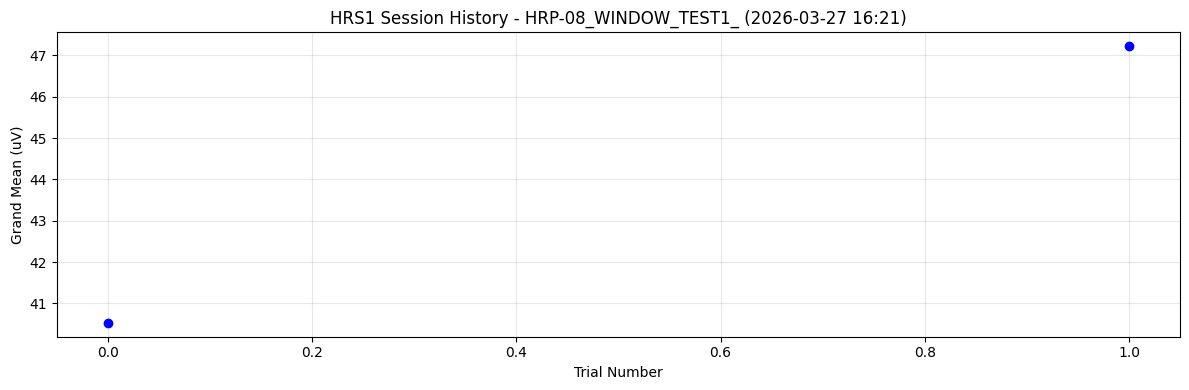

Grand mean range: [40.53, 47.22] uV
Overall mean of grand means: 43.88 uV


In [41]:
# ---- Plot HRS1: Trial Grand Means (Session History) ----
grand_means = [t.grand_mean for t in hrs1_trials]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(range(len(grand_means)), grand_means, 'o', color='blue', markersize=6)
ax.set_xlabel('Trial Number')
ax.set_ylabel('Grand Mean (uV)')
ax.set_title(f'HRS1 Session History - {hrs1_header.subject_id} ({hrs1_header.session_datetime:%Y-%m-%d %H:%M})')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Grand mean range: [{min(grand_means):.2f}, {max(grand_means):.2f}] uV")
print(f"Overall mean of grand means: {np.mean(grand_means):.2f} uV")

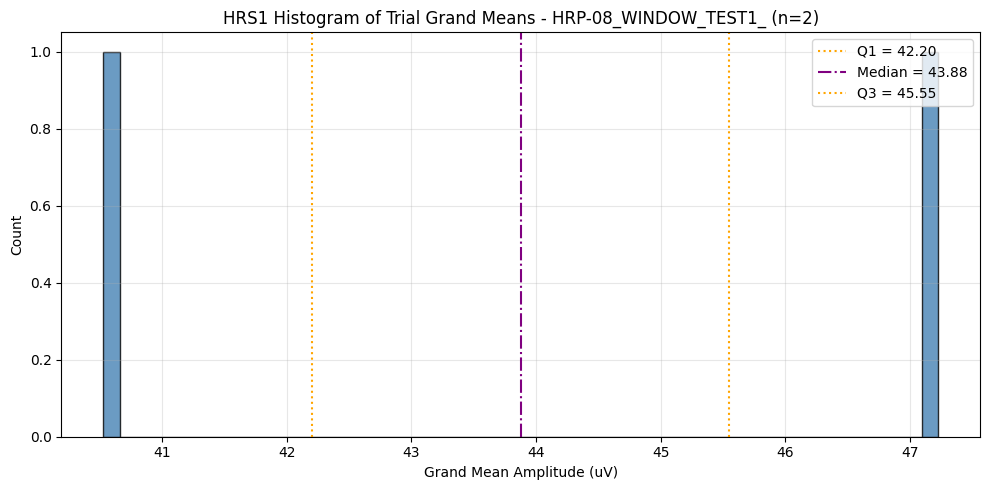

Stats: min=40.53, Q1=42.20, median=43.88, Q3=45.55, max=47.22, std=3.35


In [42]:
# ---- Plot HRS1: Histogram of Grand Means ----
gm = np.array(grand_means)

fig, ax = plt.subplots(figsize=(10, 5))
hist_vals, hist_edges, _ = ax.hist(gm, bins=50, color='steelblue', edgecolor='black', alpha=0.8)
#ax.axvline(hrs1_header.trial_initiation_uv_min, color='red', linestyle='--', linewidth=1.5, label=f'Init min = {hrs1_header.trial_initiation_uv_min}')
#ax.axvline(hrs1_header.trial_initiation_uv_max, color='red', linestyle='--', linewidth=1.5, label=f'Init max = {hrs1_header.trial_initiation_uv_max}')

q25, q50, q75 = np.percentile(gm, [25, 50, 75])
ax.axvline(q25, color='orange', linestyle=':', linewidth=1.5, label=f'Q1 = {q25:.2f}')
ax.axvline(q50, color='purple', linestyle='-.', linewidth=1.5, label=f'Median = {q50:.2f}')
ax.axvline(q75, color='orange', linestyle=':', linewidth=1.5, label=f'Q3 = {q75:.2f}')

ax.set_xlabel('Grand Mean Amplitude (uV)')
ax.set_ylabel('Count')
ax.set_title(f'HRS1 Histogram of Trial Grand Means - {hrs1_header.subject_id} (n={len(gm)})')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Stats: min={gm.min():.2f}, Q1={q25:.2f}, median={q50:.2f}, Q3={q75:.2f}, max={gm.max():.2f}, std={gm.std():.2f}")

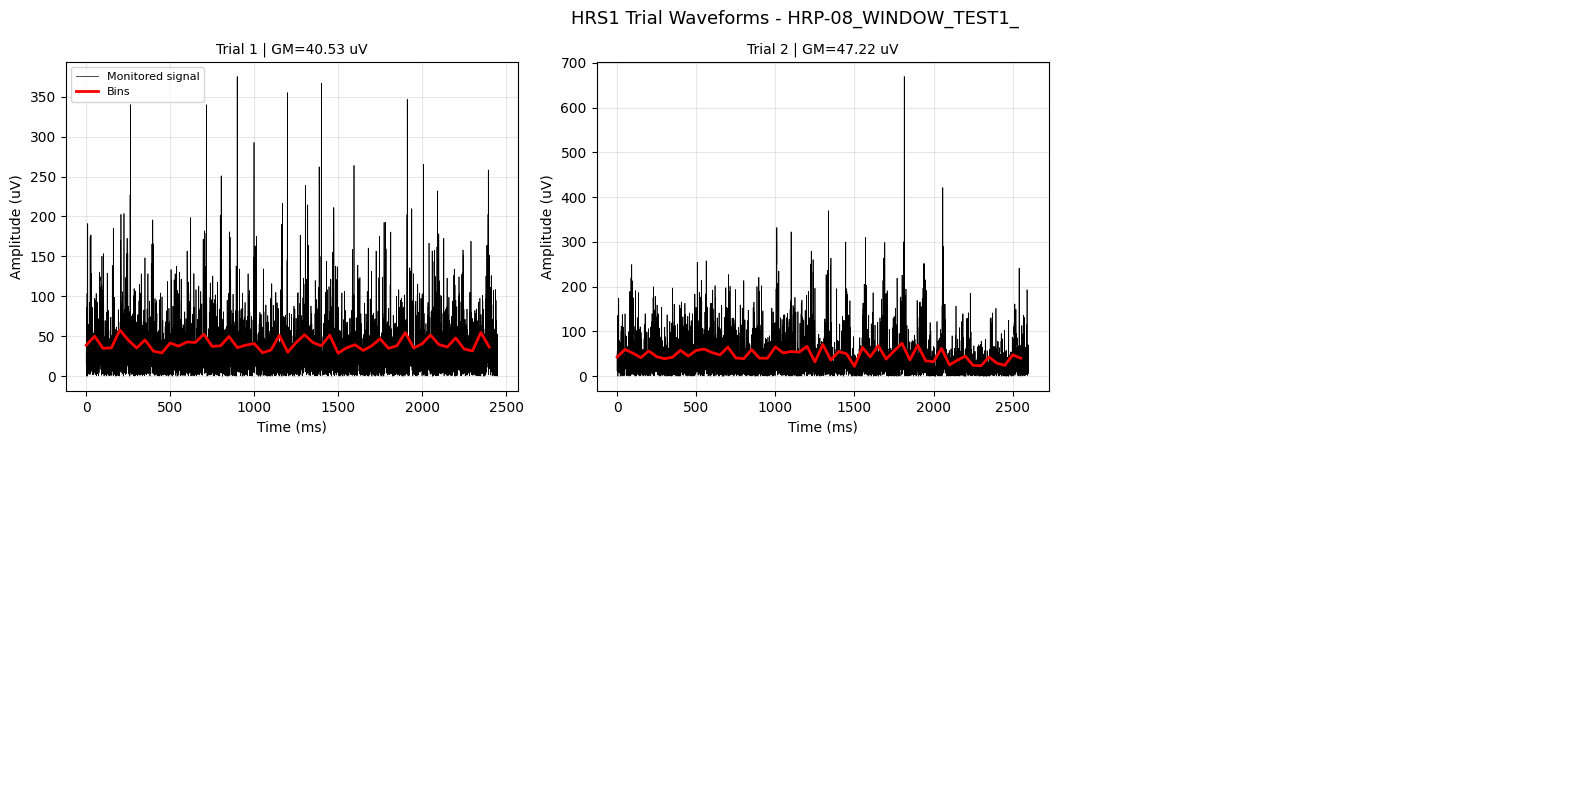

In [43]:
# ---- Plot HRS1: Individual Trial Waveforms (first 6 trials) ----
n_show = min(6, len(hrs1_trials))

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i in range(n_show):
    ax = axes[i]
    trial = hrs1_trials[i]
    sig = np.array(trial.monitored_signal)
    bins_arr = np.array(trial.bins)
    bin_sample_count = int((SAMPLE_RATE / 1000) * hrs1_header.bin_duration_ms)

    # Time axis in ms
    t_ms = np.arange(len(sig)) / SAMPLE_RATE * 1000.0

    # Plot monitored signal (abs EMG)
    ax.plot(t_ms, sig, color='black', linewidth=0.5, label='Monitored signal')

    # Plot bins
    bin_x = np.arange(len(bins_arr)) * hrs1_header.bin_duration_ms
    ax.plot(bin_x, bins_arr, color='red', linewidth=2, label='Bins')

    ax.set_title(f'Trial {i+1} | GM={trial.grand_mean:.2f} uV', fontsize=10)
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Amplitude (uV)')
    ax.grid(True, alpha=0.3)

    if i == 0:
        ax.legend(fontsize=8)

for j in range(n_show, len(axes)):
    axes[j].axis('off')

fig.suptitle(f'HRS1 Trial Waveforms - {hrs1_header.subject_id}', fontsize=13)
plt.tight_layout()
plt.show()

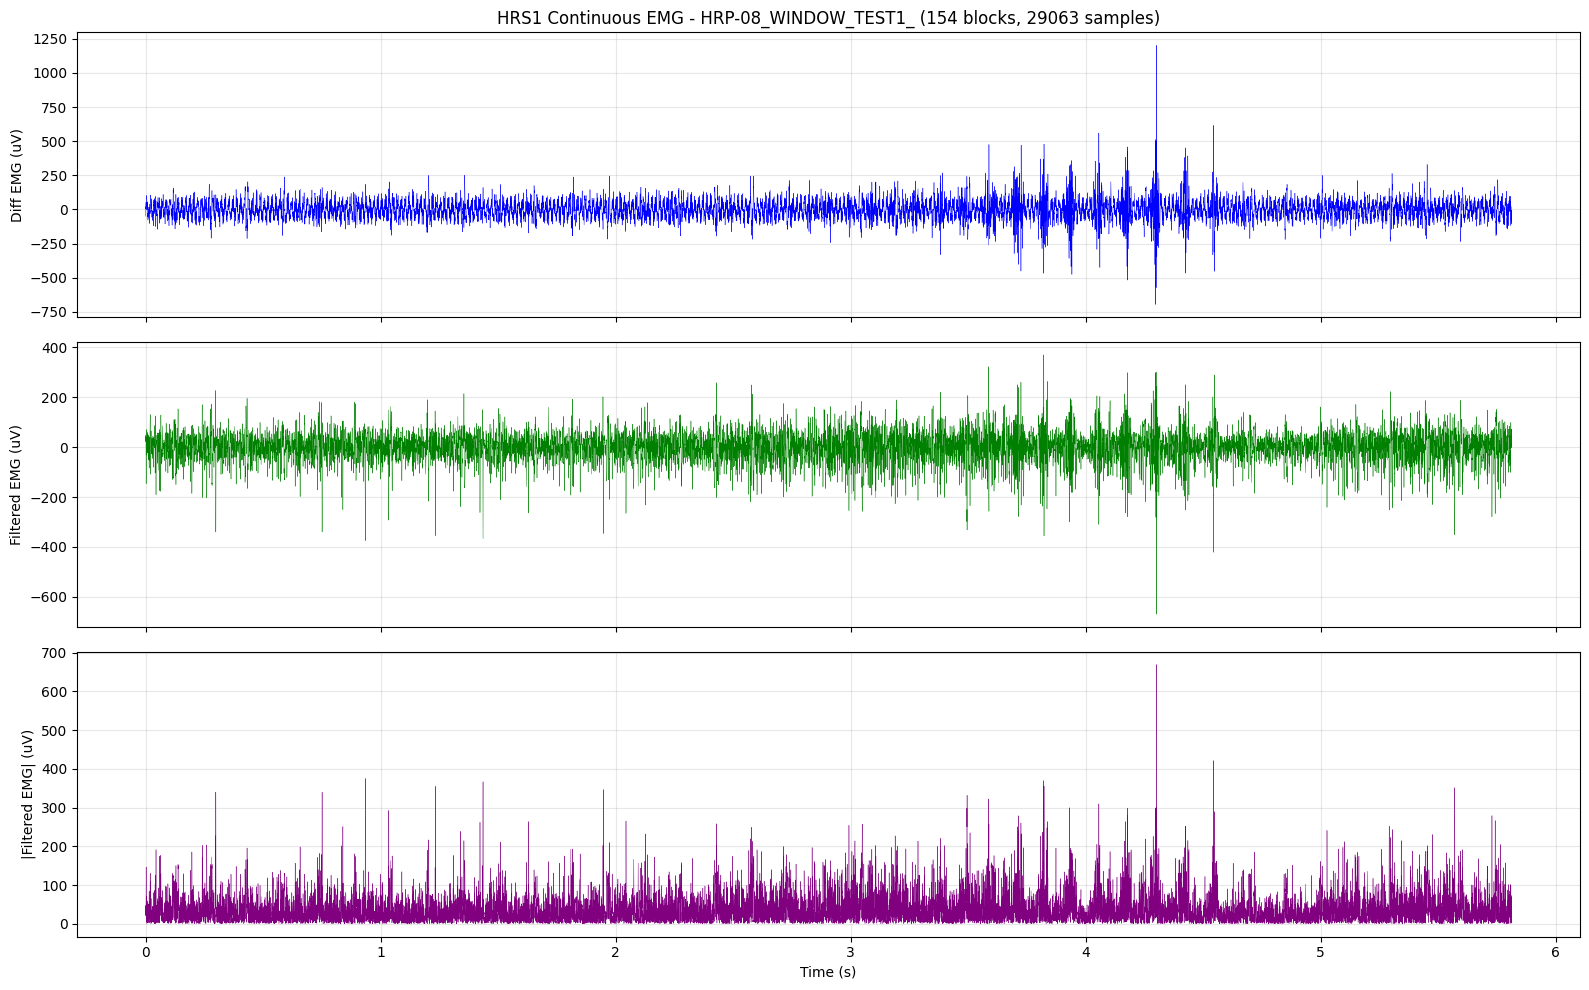

Total continuous samples: 29063, Duration: 5.8 s
Channel names: ['CH7', 'CH8', 'ADC1']


In [44]:
# ---- Plot HRS1: Continuous EMG Data (diff, filtered, abs) ----
# Concatenate all EMG blocks to reconstruct the session timeline

if len(hrs1_emg_blocks) > 0:
    all_diff = np.concatenate([b.diff for b in hrs1_emg_blocks])
    all_filt = np.concatenate([b.filtered for b in hrs1_emg_blocks])
    all_abs  = np.concatenate([b.abs_val for b in hrs1_emg_blocks])
    all_ts   = np.array([b.ts_open_ephys_sent for b in hrs1_emg_blocks])

    # Build a sample-level time axis in seconds (relative to session start)
    t_samples = np.arange(len(all_diff)) / SAMPLE_RATE

    fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

    axes[0].plot(t_samples, all_diff, color='blue', linewidth=0.3)
    axes[0].set_ylabel('Diff EMG (uV)')
    axes[0].set_title(f'HRS1 Continuous EMG - {hrs1_header.subject_id} ({len(hrs1_emg_blocks)} blocks, {len(all_diff)} samples)')
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(t_samples, all_filt, color='green', linewidth=0.3)
    axes[1].set_ylabel('Filtered EMG (uV)')
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(t_samples, all_abs, color='purple', linewidth=0.3)
    axes[2].set_ylabel('|Filtered EMG| (uV)')
    axes[2].set_xlabel('Time (s)')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"Total continuous samples: {len(all_diff)}, Duration: {t_samples[-1]:.1f} s")
    if len(hrs1_emg_blocks[0].channel_names) > 0:
        print(f"Channel names: {hrs1_emg_blocks[0].channel_names}")
else:
    print("No EMG data blocks found in this HRS1 file.")

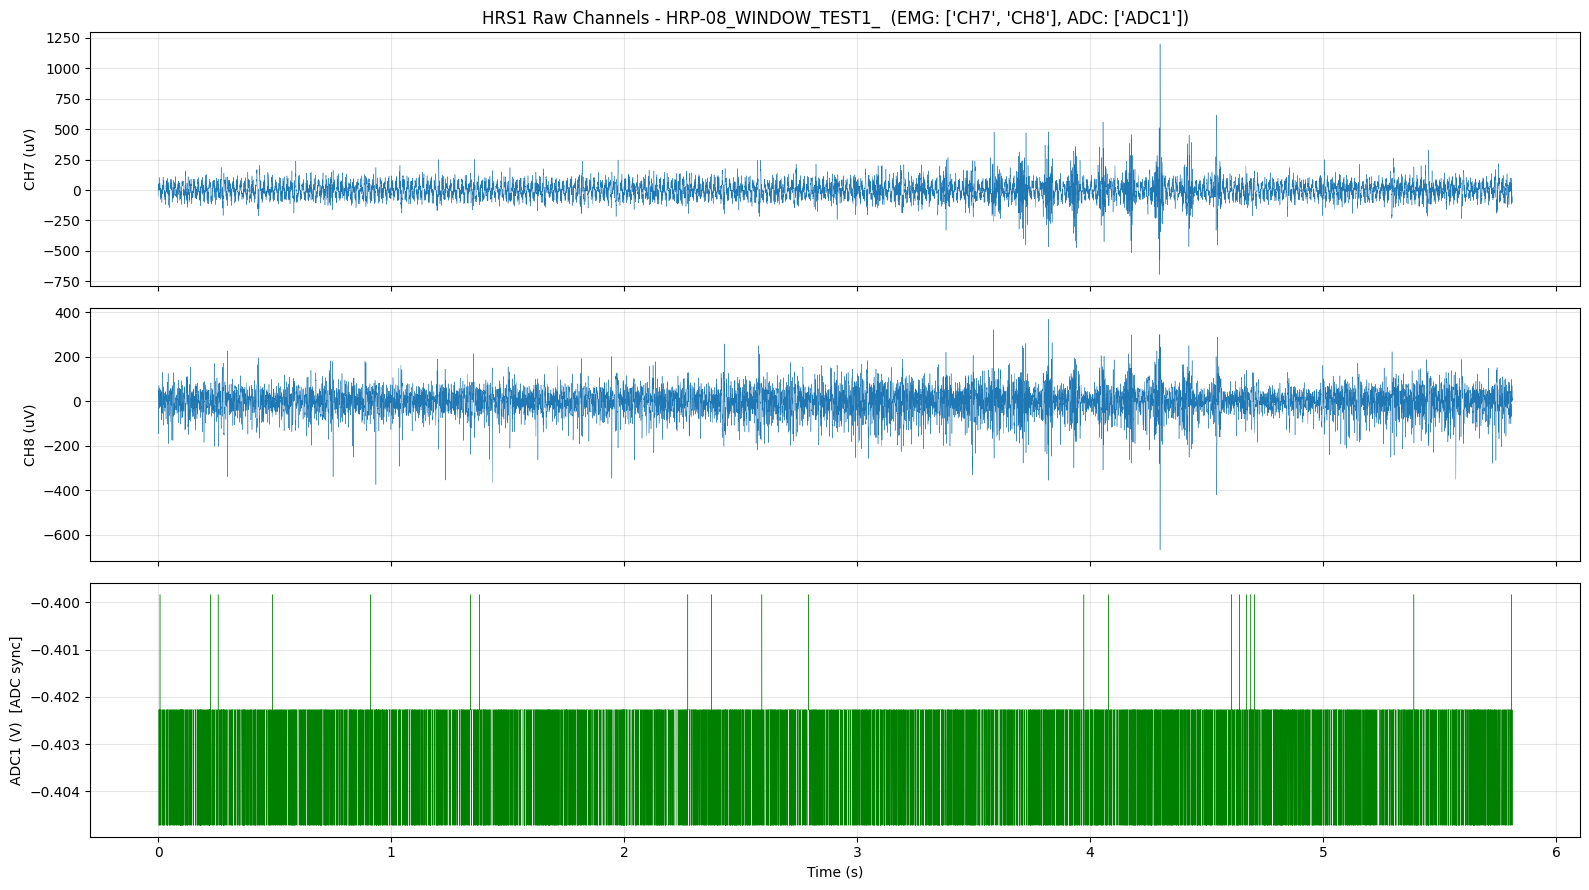

In [45]:
# ---- Plot HRS1: Raw EMG Channels (per-channel overlay) ----
# EMG channels (CH7, CH8) are plotted as EMG traces.
# The ADC sync channel (any channel whose name contains 'ADC') is plotted
# on a separate axis with its own scale.
if len(hrs1_emg_blocks) > 0 and len(hrs1_emg_blocks[0].raw_channels) >= 1:
    n_ch = len(hrs1_emg_blocks[0].raw_channels)
    ch_names = (hrs1_emg_blocks[0].channel_names
                if hrs1_emg_blocks[0].channel_names
                else [f'Ch{i}' for i in range(n_ch)])

    # Separate EMG channels from the ADC sync channel
    emg_ch_indices = [i for i, n in enumerate(ch_names) if 'ADC' not in n.upper()]
    adc_ch_indices = [i for i, n in enumerate(ch_names) if 'ADC' in n.upper()]

    n_emg = len(emg_ch_indices)
    n_adc = len(adc_ch_indices)
    n_rows = n_emg + n_adc

    fig, axes = plt.subplots(n_rows, 1, figsize=(16, 3 * n_rows), sharex=True)
    if n_rows == 1:
        axes = [axes]

    row = 0
    for ch_idx in emg_ch_indices:
        ch_data = np.concatenate([b.raw_channels[ch_idx] for b in hrs1_emg_blocks
                                  if len(b.raw_channels) > ch_idx])
        t_ch = np.arange(len(ch_data)) / SAMPLE_RATE
        axes[row].plot(t_ch, ch_data, linewidth=0.3)
        axes[row].set_ylabel(f'{ch_names[ch_idx]} (uV)')
        axes[row].grid(True, alpha=0.3)
        row += 1

    for ch_idx in adc_ch_indices:
        ch_data = np.concatenate([b.raw_channels[ch_idx] for b in hrs1_emg_blocks
                                  if len(b.raw_channels) > ch_idx])
        t_ch = np.arange(len(ch_data)) / SAMPLE_RATE
        axes[row].plot(t_ch, ch_data, color='green', linewidth=0.3)
        axes[row].set_ylabel(f'{ch_names[ch_idx]} (V)  [ADC sync]')
        axes[row].grid(True, alpha=0.3)
        row += 1

    axes[0].set_title(f'HRS1 Raw Channels - {hrs1_header.subject_id}  '
                      f'(EMG: {[ch_names[i] for i in emg_ch_indices]}, '
                      f'ADC: {[ch_names[i] for i in adc_ch_indices]})')
    axes[-1].set_xlabel('Time (s)')
    plt.tight_layout()
    plt.show()
else:
    print("No raw channel data available.")

# Section 3: Read and Explore the HRS2 File (MH Recruitment Curve)

In [46]:
# ---- Read the HRS2 file (auto-detected) ----
if hrs2_path is None:
    print("No HRS2 file found â€” skipping HRS2 read.")
    hrs2_header, hrs2_trials, hrs2_emg_blocks = None, [], []
else:
    hrs2_header, hrs2_trials, hrs2_emg_blocks = read_hrs2(hrs2_path)

    if hrs2_header.file_version == 0:
        _fv_desc = "v0: trial_data only"
    elif hrs2_header.file_version == 1:
        _fv_desc = "v1: + ADC sync_data"
    else:
        _fv_desc = "v2: + timing/sync debug fields"

    print(f"=== HRS2 Header ===")
    print(f"  File:               {os.path.basename(hrs2_path)}")
    print(f"  File version:       {hrs2_header.file_version}  ({_fv_desc})")
    print(f"  Subject ID:         {hrs2_header.subject_id}")
    print(f"  Session start time: {hrs2_header.session_start_time}")
    print(f"  Stage name:         {hrs2_header.stage_name}")
    print(f"  Stage description:  {hrs2_header.stage_description}")
    print(f"  Stage type:         {hrs2_header.stage_type}")
    print(f"\n  Trials found:       {len(hrs2_trials)}")
    print(f"  EMG data blocks:    {len(hrs2_emg_blocks)}")

    if len(hrs2_trials) > 0:
        print(f"\n=== First Trial ===")
        t0 = hrs2_trials[0]
        print(f"  Start time:         {t0.start_time}")
        print(f"  Min init threshold: {t0.min_initiation_threshold:.4f} uV")
        print(f"  Max init threshold: {t0.max_initiation_threshold:.4f} uV")
        print(f"  Stim amplitude:     {t0.stimulation_amplitude_ma:.4f} mA")
        print(f"  Trial data:         {len(t0.trial_data)} samples ({len(t0.trial_data)*MS_PER_SAMPLE:.1f} ms)")
        has_sync = len(t0.sync_data) > 1
        print(f"  ADC sync data:      {len(t0.sync_data)} samples {'(present)' if has_sync else '(empty -- file_version 0)'}")

        if hrs2_header.file_version >= 2:
            _onset_desc = 'detected' if t0.onset_detected else 'fallback -- no threshold crossing'
            print(f"\n  --- File Version 2 Timing / Sync Fields ---")
            print(f"  trigger_wall_time_ms:               {t0.trigger_wall_time_ms}")
            print(f"  onset_sample_index:                 {t0.onset_sample_index}  ({_onset_desc})")
            print(f"  onset_detected:                     {bool(t0.onset_detected)}")
            print(f"  stim_end_sample_index:              {t0.stim_end_sample_index}")
            print(f"  stim_duration_samples:              {t0.stim_duration_samples}")
            print(f"  stim_duration_ms:                   {t0.stim_duration_ms:.3f} ms")
            print(f"  sync_peak_voltage:                  {t0.sync_peak_voltage:.4f} V  (threshold = {STIM_ONSET_THRESHOLD} V)")
            print(f"  n_pre_trigger_frames_discarded:     {t0.n_pre_trigger_frames_discarded}")
            print(f"  first_post_trigger_frame_sample_id: {t0.first_post_trigger_frame_sample_id}")
            print(f"  frame_received_timestamps_ms:       {len(t0.frame_received_timestamps_ms)} entries")

        stim_amps = [t.stimulation_amplitude_ma for t in hrs2_trials]
        unique_amps = sorted(set([round(a, 2) for a in stim_amps]))
        print(f"\n=== Stimulation Summary ===")
        print(f"  Unique amplitudes (mA): {unique_amps}")
        print(f"  Total trials:           {len(hrs2_trials)}")
        for amp in unique_amps:
            count = sum(1 for a in stim_amps if round(a, 2) == amp)
            print(f"    {amp:.2f} mA : {count} trial(s)")
    else:
        print("\nNo trials found.")

    if len(hrs2_emg_blocks) > 0:
        b0 = hrs2_emg_blocks[0]
        print(f"\n=== First EMG Block ===")
        print(f"  Channel names:  {b0.channel_names}")
        print(f"  Raw channels:   {len(b0.raw_channels)} x {len(b0.raw_channels[0]) if b0.raw_channels else 0} samples")
        print(f"  Diff samples:   {len(b0.diff)}")

=== HRS2 Header ===
  File:               HRP-08_WINDOW_TEST1__20260327T162153.hrs2
  File version:       2  (v2: + timing/sync debug fields)
  Subject ID:         HRP-08_WINDOW_TEST1_
  Session start time: 2026-03-27 16:21:53.412798
  Stage name:         S2
  Stage description:  Mh Recruitment Curve
  Stage type:         1

  Trials found:       150
  EMG data blocks:    17721

=== First Trial ===
  Start time:         2026-03-27 16:22:01.927166
  Min init threshold: 43.2000 uV
  Max init threshold: 77.5100 uV
  Stim amplitude:     0.9000 mA
  Trial data:         2926 samples (585.2 ms)
  ADC sync data:      2926 samples (present)

  --- File Version 2 Timing / Sync Fields ---
  trigger_wall_time_ms:               1774646521927
  onset_sample_index:                 319  (detected)
  onset_detected:                     True
  stim_end_sample_index:              321
  stim_duration_samples:              2
  stim_duration_ms:                   0.400 ms
  sync_peak_voltage:               

# Section 3a: Initiation Thresholds Summary

Displays the EMG amplitude thresholds and timing windows used to initiate trials in both stages:

- **S1 (EMG Characterization):** fixed thresholds stored in the file header â€” the grand mean of binned absolute EMG must fall between `trial_initiation_uv_min` and `trial_initiation_uv_max`.
- **S2 (MH Recruitment Curve):** per-trial thresholds stored with each trial â€” the app derives them from the S1 histogram percentiles, so they may vary if the experimenter re-ran the calculation.

In [47]:
# ---- Initiation Thresholds Summary ----

print("=" * 62)
print("  INITIATION THRESHOLDS SUMMARY")
print("=" * 62)

# --- S1: EMG Characterization (values stored in HRS1 header) ---
print("\nS1 â€“ EMG Characterization Stage")
print(f"  Lower bound : {hrs1_header.trial_initiation_uv_min:.2f} ÂµV")
print(f"  Upper bound : {hrs1_header.trial_initiation_uv_max:.2f} ÂµV")
print(f"  (A trial is accepted when the grand mean of binned |EMG| falls within this range)")
print(f"  Monitoring window : {hrs1_header.trial_initiation_phase_min_ms}â€“{hrs1_header.trial_initiation_phase_max_ms} ms  |  Bin duration : {hrs1_header.bin_duration_ms} ms")

# --- S2: MH Recruitment Curve (lower/upper bounds stored per trial in HRS2) ---
print("\nS2 â€“ MH Recruitment Curve Stage")
if hrs2_header is None or len(hrs2_trials) == 0:
    print("  No HRS2 file / no trials found.")
else:
    s2_mins = [t.min_initiation_threshold for t in hrs2_trials]
    s2_maxs = [t.max_initiation_threshold for t in hrs2_trials]
    all_same = (len(set(round(v, 4) for v in s2_mins)) == 1 and
                len(set(round(v, 4) for v in s2_maxs)) == 1)
    if all_same:
        print(f"  Lower bound : {s2_mins[0]:.4f} ÂµV  (constant across all {len(hrs2_trials)} trials)")
        print(f"  Upper bound : {s2_maxs[0]:.4f} ÂµV  (constant across all {len(hrs2_trials)} trials)")
    else:
        print(f"  Thresholds varied across {len(hrs2_trials)} trials:")
        print(f"  {'Trial':>6}  {'Lower bound (ÂµV)':>18}  {'Upper bound (ÂµV)':>18}")
        for i, (mn, mx) in enumerate(zip(s2_mins, s2_maxs)):
            print(f"  {i + 1:>6}  {mn:>18.4f}  {mx:>18.4f}")

print("\n" + "=" * 62)

  INITIATION THRESHOLDS SUMMARY

S1 â€“ EMG Characterization Stage
  Lower bound : 15.00 ÂµV
  Upper bound : 300.00 ÂµV
  (A trial is accepted when the grand mean of binned |EMG| falls within this range)
  Monitoring window : 2200â€“2700 ms  |  Bin duration : 50 ms

S2 â€“ MH Recruitment Curve Stage
  Lower bound : 43.2000 ÂµV  (constant across all 150 trials)
  Upper bound : 77.5100 ÂµV  (constant across all 150 trials)



In [48]:
# ---- Stimulus Amplitude per Trial ----
if hrs2_trials:
    from collections import defaultdict

    amp_to_trials = defaultdict(list)
    for i, t in enumerate(hrs2_trials):
        amp_to_trials[round(t.stimulation_amplitude_ma, 2)].append(i)

    print(f"{'Trial':>6}  {'Amplitude (mA)':>15}")
    print('-' * 24)
    for i, t in enumerate(hrs2_trials):
        print(f"{i:>6}  {t.stimulation_amplitude_ma:>15.2f}")

    print()
    print(f"{'Amplitude (mA)':>15}  Trials")
    print('-' * 40)
    for amp in sorted(amp_to_trials):
        print(f"{amp:>15.2f}  {amp_to_trials[amp]}")


 Trial   Amplitude (mA)
------------------------
     0             0.90
     1             1.10
     2             1.20
     3             0.70
     4             0.60
     5             1.30
     6             1.90
     7             1.00
     8             0.40
     9             0.10
    10             1.60
    11             0.20
    12             2.00
    13             0.50
    14             0.00
    15             0.60
    16             0.30
    17             1.10
    18             0.80
    19             0.00
    20             0.10
    21             1.00
    22             1.30
    23             0.70
    24             1.90
    25             1.70
    26             0.40
    27             1.80
    28             1.60
    29             1.20
    30             2.00
    31             0.50
    32             0.20
    33             0.90
    34             1.40
    35             1.50
    36             1.40
    37             0.00
    38             0.50
    39         

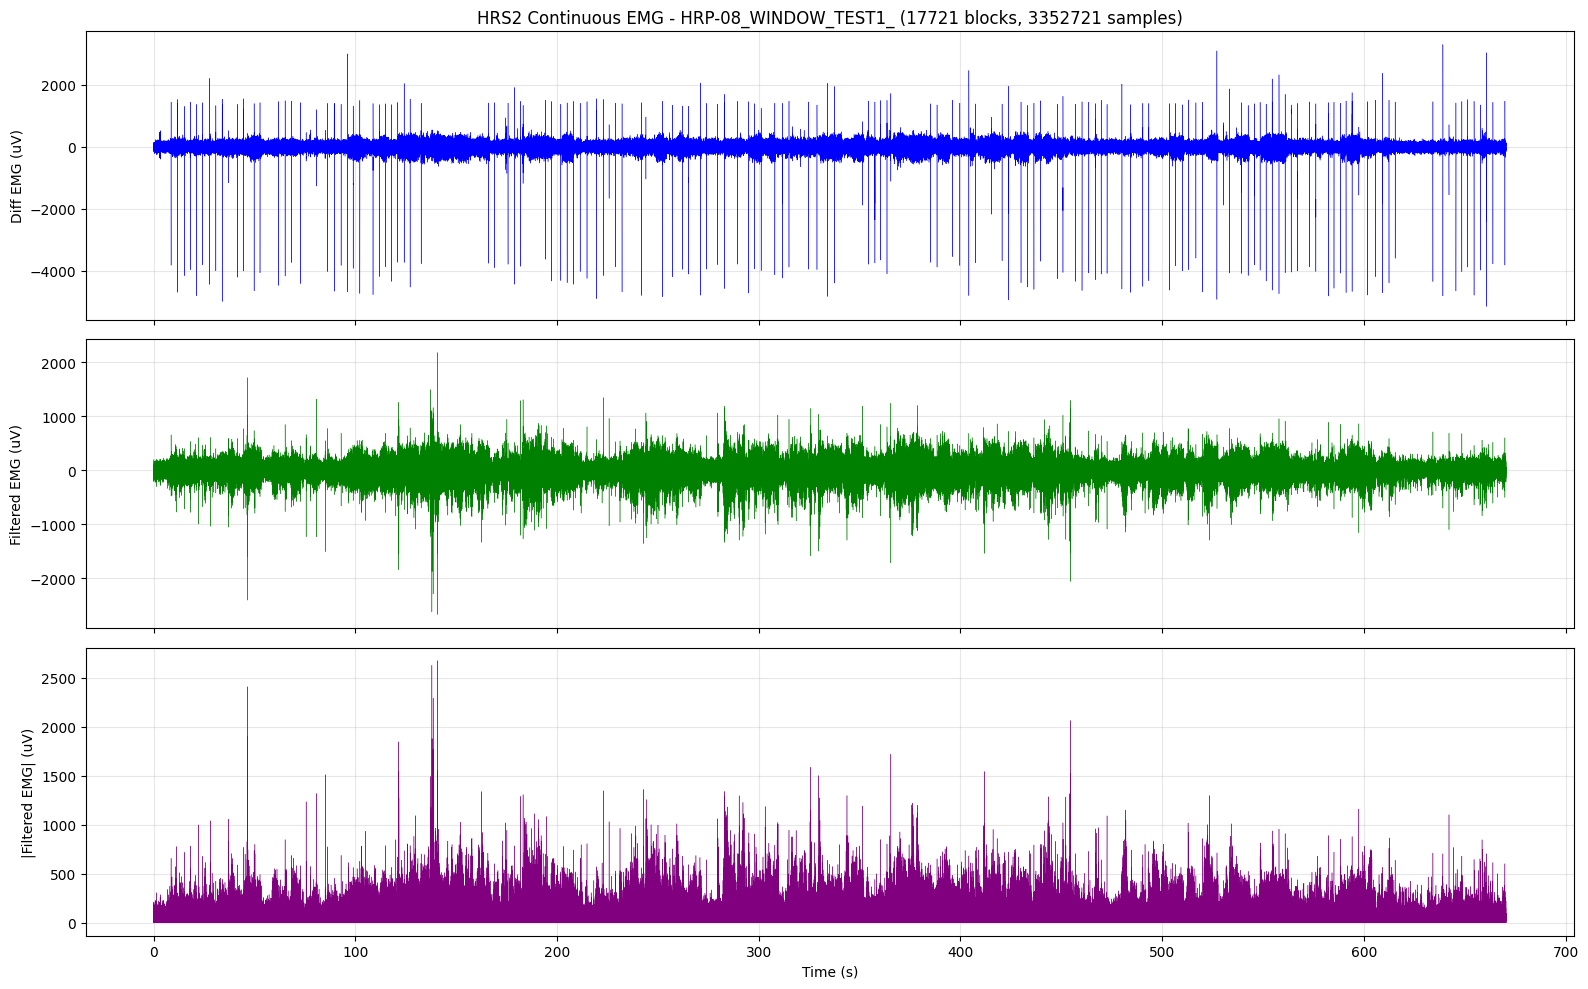

Total continuous samples: 3352721, Duration: 670.5 s


In [49]:
# ---- Plot HRS2: Continuous EMG Data ----
if len(hrs2_emg_blocks) > 0:
    all_diff_s2 = np.concatenate([b.diff for b in hrs2_emg_blocks])
    all_filt_s2 = np.concatenate([b.filtered for b in hrs2_emg_blocks])
    all_abs_s2  = np.concatenate([b.abs_val for b in hrs2_emg_blocks])

    t_s2 = np.arange(len(all_diff_s2)) / SAMPLE_RATE

    fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

    axes[0].plot(t_s2, all_diff_s2, color='blue', linewidth=0.3)
    axes[0].set_ylabel('Diff EMG (uV)')
    axes[0].set_title(f'HRS2 Continuous EMG - {hrs2_header.subject_id} ({len(hrs2_emg_blocks)} blocks, {len(all_diff_s2)} samples)')
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(t_s2, all_filt_s2, color='green', linewidth=0.3)
    axes[1].set_ylabel('Filtered EMG (uV)')
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(t_s2, all_abs_s2, color='purple', linewidth=0.3)
    axes[2].set_ylabel('|Filtered EMG| (uV)')
    axes[2].set_xlabel('Time (s)')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"Total continuous samples: {len(all_diff_s2)}, Duration: {t_s2[-1]:.1f} s")
else:
    print("No EMG data blocks found in this HRS2 file.")

In [50]:
shared_ylim = (-1500, 1500)  # Set a common y-axis limit for all trial plots

In [51]:
# ---- Plot HRS2: Interactive Trial Viewer ----
# Paged 2x3 grid with per-trial zoom and ADC sync overlay toggle.
# M- and H-wave windows are shaded on every panel.
# Requires an interactive Jupyter kernel (ipywidgets).

from ipywidgets import Button, Output, HBox, VBox, Dropdown, Label, ToggleButton
from matplotlib.patches import Patch

#  Configuration 
PRE_PLOT_MS  = 2   # ms before stim onset to display
POST_PLOT_MS = 15  # ms after  stim onset to display
N_PER_PAGE   = 6   # trials shown per page (2 rows x 3 cols)

# M/H wave window constants (ms relative to stim onset)
_M_WAVE_START_MS = 2.5
_M_WAVE_END_MS   = 4.0
_H_WAVE_START_MS = 6.0
_H_WAVE_END_MS   = 10.0

#  Build plot-ready list (uses get_trial_window from helpers) 
trial_plot_data = []
for _i, _tr in enumerate(hrs2_trials):
    _t, _emg, _adc, _end = get_trial_window(_tr, PRE_PLOT_MS, POST_PLOT_MS)
    trial_plot_data.append({
        'idx': _i, 'trial': _tr,
        't_ms': _t, 'emg': _emg, 'adc': _adc,
        'stim_end_ms': _end,
        'amp': _tr.stimulation_amplitude_ma,
    })

if len(trial_plot_data) == 0:
    print("No HRS2 trials to display.")
else:
    #  Shared EMG y-limits
    _all_emg = np.concatenate([d['emg'] for d in trial_plot_data])
    _lo, _hi = float(np.nanmin(_all_emg)), float(np.nanmax(_all_emg))
    _pad = max(0.08 * (_hi - _lo), 1.0)
    shared_ylim1 = (_lo - _pad, _hi + _pad)

    #  Pages
    pages = [trial_plot_data[i:i+N_PER_PAGE]
             for i in range(0, len(trial_plot_data), N_PER_PAGE)]
    current_page = {'idx': 0}
    show_adc     = {'val': True}

    out = Output()
    trial_dropdown = Dropdown(description='Trial:')

    #  Core draw helper
    def _draw_trial(ax, d, adc_on, small=True):
        """Render one trial into ax. Returns secondary ADC axis or None."""
        lw   = 1.0 if small else 1.8
        fsz  = 8   if small else 11
        t, emg, adc, end_ms = d['t_ms'], d['emg'], d['adc'], d['stim_end_ms']

        ax.plot(t, emg, color='black', linewidth=lw)
        h_onset = ax.axvline(0, color='blue', linestyle='--', linewidth=lw,
                             label='Stim onset')
        ax.set_xlim(-PRE_PLOT_MS, POST_PLOT_MS)
        ax.set_xlabel('Time (ms)', fontsize=fsz)
        ax.set_ylabel('EMG (µV)',  fontsize=fsz)
        ax.tick_params(labelsize=fsz - 1)
        ax.grid(True, alpha=0.3)
        ax.set_ylim(shared_ylim)
        #ax.set_ylim(shared_ylim1)

        legend_h = [h_onset]
        legend_l = ['Stim onset']

        if end_ms is not None:
            h_end = ax.axvline(end_ms, color='purple', linestyle='--', linewidth=lw,
                               label=f'Stim end ({end_ms:.1f} ms)')
            legend_h.append(h_end)
            legend_l.append(f'Stim end ({end_ms:.1f} ms)')

        # M/H wave region overlays
        ax.axvspan(_M_WAVE_START_MS, _M_WAVE_END_MS, color='blue',  alpha=0.12, zorder=0)
        ax.axvspan(_H_WAVE_START_MS, _H_WAVE_END_MS, color='green', alpha=0.12, zorder=0)
        legend_h += [Patch(facecolor='blue', alpha=0.4), Patch(facecolor='green', alpha=0.4)]
        legend_l += ['M-wave (2.5–4 ms)', 'H-wave (6–10 ms)']

        ax_adc = None
        if adc_on and adc is not None:
            ax_adc = ax.twinx()
            h_adc, = ax_adc.plot(t, adc, color='green', linewidth=lw * 0.7,
                                 alpha=0.85, label='ADC (V)')
            ax_adc.set_ylabel('ADC (V)', color='green', fontsize=fsz - 1)
            ax_adc.tick_params(axis='y', labelcolor='green', labelsize=fsz - 2)
            legend_h.append(h_adc)
            legend_l.append('ADC (V)')

        ax.legend(legend_h, legend_l, fontsize=fsz - 2, loc='upper right')
        return ax_adc

    #  Grid page renderer
    def plot_page(page_idx):
        with out:
            out.clear_output(wait=True)
            page = pages[page_idx]
            n    = len(page)

            trial_dropdown.options = [
                (f"Trial {d['idx']+1}  |  {d['amp']:.2f} mA", d['idx'])
                for d in page
            ]
            if trial_dropdown.options:
                trial_dropdown.value = page[0]['idx']

            fig, axs = plt.subplots(2, 3, figsize=(15, 7))
            axs_flat = axs.flatten()

            for j in range(N_PER_PAGE):
                ax = axs_flat[j]
                if j < n:
                    d = page[j]
                    _draw_trial(ax, d, show_adc['val'], small=True)
                    ax.set_title(f"Trial {d['idx']+1}  |  {d['amp']:.2f} mA", fontsize=9)
                else:
                    ax.axis('off')

            n_shown_start = N_PER_PAGE * page_idx + 1
            n_shown_end   = min(N_PER_PAGE * (page_idx + 1), len(trial_plot_data))
            fig.suptitle(
                f"{hrs2_header.subject_id}    "
                f"Trials {n_shown_start}–{n_shown_end} of {len(trial_plot_data)}"
                f"  (Page {page_idx+1}/{len(pages)})",
                fontsize=11
            )
            plt.tight_layout()
            plt.show()

            try:
                def _on_click(event):
                    if event.inaxes is None:
                        return
                    for k, ax in enumerate(axs_flat):
                        if event.inaxes is ax and k < n:
                            if getattr(event, 'dblclick', False):
                                show_zoom(page[k]['idx'])
                            else:
                                trial_dropdown.value = page[k]['idx']
                            break
                fig.canvas.mpl_connect('button_press_event', _on_click)
            except Exception:
                pass

    #  Single-trial zoom renderer
    def show_zoom(trial_idx):
        d = trial_plot_data[trial_idx]
        with out:
            out.clear_output(wait=True)
            fig, ax = plt.subplots(figsize=(13, 5))
            _draw_trial(ax, d, show_adc['val'], small=False)
            ax.set_title(
                f"Trial {d['idx']+1}  |  Stim = {d['amp']:.2f} mA  |  "
                f"{hrs2_header.subject_id}  "
                f"({hrs2_header.session_start_time:%Y-%m-%d %H:%M})",
                fontsize=11
            )
            plt.tight_layout()
            plt.show()

            back_btn = Button(description='Back to grid', button_style='info')
            back_btn.on_click(lambda b: plot_page(current_page['idx']))
            display(back_btn)

    #  Navigation callbacks
    def on_prev(b):
        if current_page['idx'] > 0:
            current_page['idx'] -= 1
            page_drop.value = current_page['idx']
            plot_page(current_page['idx'])

    def on_next(b):
        if current_page['idx'] < len(pages) - 1:
            current_page['idx'] += 1
            page_drop.value = current_page['idx']
            plot_page(current_page['idx'])

    def on_page_change(change):
        if change['name'] == 'value' and change['new'] != current_page['idx']:
            current_page['idx'] = change['new']
            plot_page(current_page['idx'])

    def on_view(b):
        try:
            show_zoom(int(trial_dropdown.value))
        except Exception as e:
            print(f'Could not zoom trial: {e}')

    def on_adc_toggle(change):
        show_adc['val'] = bool(change['new'])
        plot_page(current_page['idx'])

    #  Build controls
    prev_btn   = Button(description='Prev',      button_style='')
    next_btn   = Button(description='Next',      button_style='primary')
    page_drop  = Dropdown(
        options=[(f'Page {i+1}', i) for i in range(len(pages))],
        description='Page:', layout={'width': '130px'}
    )
    view_btn   = Button(description='View trial',  button_style='info')
    adc_toggle = ToggleButton(
        value=True, description='ADC overlay',
        button_style='success',
        tooltip='Show/hide ADC sync line on all plots'
    )

    prev_btn.on_click(on_prev)
    next_btn.on_click(on_next)
    page_drop.observe(on_page_change, names='value')
    view_btn.on_click(on_view)
    adc_toggle.observe(on_adc_toggle, names='value')

    controls = HBox([
        prev_btn, next_btn, page_drop,
        Label('  '), trial_dropdown, view_btn,
        Label('  '), adc_toggle
    ])

    print(f"Loaded {len(trial_plot_data)} trials across {len(pages)} page(s).")
    print(f"Shared EMG y-axis: [{shared_ylim[0]:.1f}, {shared_ylim[1]:.1f}] µV")
    print("Double-click a subplot to zoom in, or use the dropdown + 'View trial' button.")

    display(VBox([controls, out]))
    plot_page(0)

Loaded 150 trials across 25 page(s).
Shared EMG y-axis: [-1500.0, 1500.0] µV
Double-click a subplot to zoom in, or use the dropdown + 'View trial' button.


In [52]:
_end

0.4

In [53]:
# ---- Failed Trial Detector ----
# classify_trials() is defined in helpers.py.
# For file_version >= 2 it uses pre-computed fields (onset_detected, sync_peak_voltage, etc.)
# stored directly in each trial object; for older files it re-derives them from sync_data.

trial_report = classify_trials(hrs2_trials, file_version=hrs2_header.file_version)

failed = [r for r in trial_report if r['failed']]
passed = [r for r in trial_report if not r['failed']]

print(f"File version : {hrs2_header.file_version}  "
      f"({'pre-computed fields used' if hrs2_header.file_version >= 2 else 'fields derived from sync_data'})")
print(f"Total trials : {len(trial_report)}")
print(f"Passed       : {len(passed)}")
print(f"Failed       : {len(failed)}")
print()

if failed:
    v2 = hrs2_header.file_version >= 2
    hdr = (f"{'Trial':>6}  {'Amp':>6}  {'ADC peak':>9}  {'Noise std':>10}  "
           f"{'Stim dur ms':>11}  {'Discarded':>9}  Reason")
    print(hdr)
    print("-" * len(hdr))
    for r in failed:
        reason = ("no sync data" if not r['has_sync']
                  else f"ADC peak {r['adc_peak']:.3f} V < {STIM_ONSET_THRESHOLD} V threshold")
        dur_str  = f"{r['stim_duration_ms']:.2f}" if r['stim_duration_ms'] else "â€”"
        disc_str = str(r['n_pre_trigger_frames_discarded']) if v2 else "n/a"
        print(f"{r['idx']+1:>6}  {r['amp_ma']:>6.2f}  {r['adc_peak']:>9.3f}  "
              f"{r['adc_noise_std']:>10.4f}  {dur_str:>11}  {disc_str:>9}  {reason}")
else:
    print("No failed trials detected.")

File version : 2  (pre-computed fields used)
Total trials : 150
Passed       : 150
Failed       : 0

No failed trials detected.


In [54]:
# ---- Debug: Â±10 s context window from continuous data around trial onset ----
# Shows EMG (filtered) and ADC sync line (abs) pulled from hrs2_emg_blocks.
# Default TRIAL_IDX is the first failed trial; change to inspect any trial.

import importlib, helpers as _helpers_mod
importlib.reload(_helpers_mod)
from helpers import get_trial_context_window

# Default to first failed trial if any exist; otherwise use index 1
TRIAL_IDX = (failed[0]['idx'] + 1) if failed else 1  # 1-indexed
_tr = hrs2_trials[TRIAL_IDX - 1]

_ctx = get_trial_context_window(_tr, hrs2_emg_blocks, pre_s=10.0, post_s=10.0)

if _ctx is None:
    print(f"Trial {TRIAL_IDX}: cannot locate onset in continuous data.\n"
          f"  first_post_trigger_frame_sample_id = {_tr.first_post_trigger_frame_sample_id}\n"
          f"  onset_sample_index                 = {_tr.onset_sample_index}\n"
          f"  trigger_wall_time_ms               = {_tr.trigger_wall_time_ms}")
else:
    _t_s, _emg_ctx, _onset_i, _adc_ctx = _ctx
    _adc_abs = np.abs(_adc_ctx) if _adc_ctx is not None else None

    print(f"Trial {TRIAL_IDX} | Stim: {_tr.stimulation_amplitude_ma:.2f} mA  |  onset_detected={getattr(_tr, 'onset_detected', '?')}")
    print(f"  Context window : {_t_s[0]:.1f} s â†’ {_t_s[-1]:.1f} s  ({len(_t_s)} samples)")
    print(f"  EMG range      : [{_emg_ctx.min():.2f}, {_emg_ctx.max():.2f}] ÂµV")
    print(f"  onset @ index  : {_onset_i}  (t = {_t_s[_onset_i]:.4f} s)")

    # â”€â”€ Find the first pulse in |ADC| that crosses the threshold AFTER the sensed onset â”€â”€
    _pulse_i   = None
    _pulse_t_s = None
    _delay_ms  = None
    if _adc_abs is not None:
        _post = _adc_abs[_onset_i:]
        _cands = np.where(_post >= STIM_ONSET_THRESHOLD)[0]
        if len(_cands) > 0:
            _pulse_i   = _onset_i + int(_cands[0])
            _pulse_t_s = float(_t_s[_pulse_i])
            _delay_ms  = _pulse_t_s * 1000.0  # t_s is already re: onset, so delay = pulse_t_s

    if _adc_abs is not None:
        print(f"  ADC range (abs): [{_adc_abs.min():.3f}, {_adc_abs.max():.3f}] V  "
              f"(peak = {_adc_abs.max():.3f} V vs threshold {STIM_ONSET_THRESHOLD} V)")
    if _pulse_i is not None:
        print(f"\n  â”€â”€ Post-onset pulse â”€â”€")
        print(f"     Sample index in window : {_pulse_i}")
        print(f"     Time re: onset         : {_pulse_t_s:.4f} s  ({_pulse_t_s*1000:.2f} ms)")
        print(f"     Delay from sensed onset: {_delay_ms:.2f} ms")
    else:
        print(f"\n  No ADC pulse >= {STIM_ONSET_THRESHOLD} V found after sensed onset.")

    fig, (ax_emg, ax_adc) = plt.subplots(2, 1, figsize=(16, 6), sharex=True,
                                          gridspec_kw={'height_ratios': [2, 1]})

    # --- EMG subplot ---
    ax_emg.plot(_t_s, _emg_ctx, color='black', linewidth=0.5, label='Filtered EMG')
    ax_emg.axvline(0, color='red', linestyle='--', linewidth=1.2, label='Sensed onset (t = 0)')
    if _pulse_t_s is not None:
        ax_emg.axvline(_pulse_t_s, color='orange', linestyle=':', linewidth=1.2,
                       label=f'ADC pulse (+{_delay_ms:.1f} ms)')
    ax_emg.axvspan(-10, 0, color='blue',  alpha=0.04, label='Pre-onset 10 s')
    ax_emg.axvspan(  0, 10, color='green', alpha=0.04, label='Post-onset 10 s')
    ax_emg.set_ylabel('EMG (ÂµV)')
    ax_emg.set_title(
        f"Trial {TRIAL_IDX}  |  {_tr.stimulation_amplitude_ma:.2f} mA  |  "
        f"onset_detected={getattr(_tr, 'onset_detected', '?')}  |  "
        f"Â±10 s continuous context  â€”  {hrs2_header.subject_id}"
    )
    ax_emg.legend(fontsize=8, loc='upper right')
    ax_emg.grid(True, alpha=0.3)

    # --- ADC sync subplot (abs) ---
    if _adc_abs is not None:
        ax_adc.plot(_t_s, _adc_abs, color='green', linewidth=0.6, label='|ADC sync| (V)')
        ax_adc.axhline(STIM_ONSET_THRESHOLD, color='red', linestyle='--', linewidth=1.0,
                       label=f'Onset threshold ({STIM_ONSET_THRESHOLD} V)')
        ax_adc.axvline(0, color='red', linestyle='--', linewidth=1.2, label='Sensed onset (t = 0)')
        if _pulse_t_s is not None:
            ax_adc.axvline(_pulse_t_s, color='orange', linestyle=':', linewidth=1.2,
                           label=f'First post-onset pulse (t = {_pulse_t_s*1000:.2f} ms, delay = {_delay_ms:.1f} ms)')
            ax_adc.annotate(f'+{_delay_ms:.1f} ms',
                            xy=(_pulse_t_s, STIM_ONSET_THRESHOLD),
                            xytext=(_pulse_t_s + 0.2, STIM_ONSET_THRESHOLD * 1.15),
                            fontsize=8, color='orange',
                            arrowprops=dict(arrowstyle='->', color='orange', lw=1.0))
        ax_adc.set_ylabel('|ADC| (V)')
        ax_adc.legend(fontsize=8, loc='upper right')
        ax_adc.grid(True, alpha=0.3)
    else:
        ax_adc.text(0.5, 0.5, 'ADC channel not available in continuous blocks',
                    transform=ax_adc.transAxes, ha='center', va='center', color='gray')

    ax_adc.set_xlabel('Time re: onset (s)')
    plt.tight_layout()
    plt.show()


Trial 1: cannot locate onset in continuous data.
  first_post_trigger_frame_sample_id = 4644997
  onset_sample_index                 = 319
  trigger_wall_time_ms               = 1774646521927


In [55]:
TRIAL_IDX


1

In [56]:
# ---- Plot corrected trial for failed trial #1 ----
# Re-zeros the trial window around the first post-onset ADC pulse (_pulse_i),
# using the delay calculated in the debug cell above.
# Slices directly from the continuous context arrays so the corrected onset
# is guaranteed to be in-window even when the original trial_data missed it.

_PRE_MS  = PRE_PLOT_MS   # ms before corrected onset  (re-uses interactive viewer config)
_POST_MS = POST_PLOT_MS  # ms after  corrected onset

if '_pulse_i' not in dir() or _pulse_i is None:
    print("Run the debug cell above first â€” _pulse_i / _delay_ms not yet computed.")
elif _ctx is None:
    print("Context window unavailable â€” cannot build corrected trial.")
else:
    _pre_samp  = int(_PRE_MS  / 1000.0 * SAMPLE_RATE)
    _post_samp = int(_POST_MS / 1000.0 * SAMPLE_RATE)

    _c_start = _pulse_i - _pre_samp
    _c_end   = _pulse_i + _post_samp

    if _c_start < 0 or _c_end > len(_emg_ctx):
        print(f"Corrected window [{_c_start}, {_c_end}] out of range "
              f"(context has {len(_emg_ctx)} samples). Widen pre_s/post_s in the debug cell.")
    else:
        _emg_c  = _emg_ctx[_c_start:_c_end]
        _adc_c  = _adc_abs[_c_start:_c_end]
        _t_ms_c = (np.arange(len(_emg_c)) - _pre_samp) * MS_PER_SAMPLE  # ms, zeroed at corrected onset

        # Stim-end: first sample where |ADC| drops below STIM_END_THRESHOLD after corrected onset
        _stim_end_ms_c = None
        _post_adc = _adc_abs[_pulse_i:]
        _end_cands = np.where(_post_adc < STIM_END_THRESHOLD)[0]
        if len(_end_cands) > 0:
            _stim_end_ms_c = float(_end_cands[0]) * MS_PER_SAMPLE

        print(f"Corrected trial {TRIAL_IDX}  |  {_tr.stimulation_amplitude_ma:.2f} mA")
        print(f"  Original sensed onset    : sample {_onset_i} in context  (t = 0.000 s)")
        print(f"  ADC pulse (corrected t=0): sample {_pulse_i} in context  "
              f"(t = {_pulse_t_s*1000:.2f} ms after sensed onset)")
        print(f"  Delay applied            : {_delay_ms:.2f} ms  ({int(round(_delay_ms / MS_PER_SAMPLE))} samples)")
        if _stim_end_ms_c is not None:
            print(f"  Stim end (corrected)     : {_stim_end_ms_c:.2f} ms after corrected onset")

        # â”€â”€ Plot in _draw_trial style â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
        lw, fsz = 1.8, 11
        fig, ax = plt.subplots(figsize=(13, 5))

        ax.plot(_t_ms_c, _emg_c, color='black', linewidth=lw)
        h_onset = ax.axvline(0, color='blue', linestyle='--', linewidth=lw,
                             label='Stim onset (corrected)')
        ax.set_xlim(-_PRE_MS, _POST_MS)
        ax.set_xlabel('Time (ms)', fontsize=fsz)
        ax.set_ylabel('EMG (ÂµV)',  fontsize=fsz)
        ax.tick_params(labelsize=fsz - 1)
        ax.grid(True, alpha=0.3)
        ax.set_ylim(shared_ylim)

        legend_h = [h_onset]
        legend_l = ['Stim onset (corrected)']

        if _stim_end_ms_c is not None:
            h_end = ax.axvline(_stim_end_ms_c, color='purple', linestyle='--', linewidth=lw,
                               label=f'Stim end ({_stim_end_ms_c:.1f} ms)')
            legend_h.append(h_end)
            legend_l.append(f'Stim end ({_stim_end_ms_c:.1f} ms)')

        ax_adc2 = ax.twinx()
        h_adc, = ax_adc2.plot(_t_ms_c, _adc_c, color='green', linewidth=lw * 0.7,
                               alpha=0.85, label='|ADC| (V)')
        ax_adc2.axhline(STIM_ONSET_THRESHOLD, color='red', linestyle=':', linewidth=0.9,
                        alpha=0.6, label=f'Threshold ({STIM_ONSET_THRESHOLD} V)')
        ax_adc2.set_ylabel('|ADC| (V)', color='green', fontsize=fsz - 1)
        ax_adc2.tick_params(axis='y', labelcolor='green', labelsize=fsz - 2)
        legend_h += [h_adc]
        legend_l += ['|ADC| (V)']

        ax.legend(legend_h, legend_l, fontsize=fsz - 2, loc='upper right')
        ax.set_title(
            f"Trial {TRIAL_IDX}  |  {_tr.stimulation_amplitude_ma:.2f} mA  |  "
            f"Corrected onset (delay = {_delay_ms:.1f} ms)  â€”  {hrs2_header.subject_id}",
            fontsize=fsz
        )
        plt.tight_layout()
        plt.show()


Run the debug cell above first â€” _pulse_i / _delay_ms not yet computed.


In [57]:

# ---- Plot HRS2: Failed Trial Context Windows ----
# Shows every failed trial as a Â±10 s window pulled directly from hrs2_emg_blocks,
# with the detected onset zeroed at t = 0.

import importlib, helpers as _helpers_mod
importlib.reload(_helpers_mod)
from helpers import get_trial_context_window

CONTEXT_PRE_S  = 10.0   # seconds before onset
CONTEXT_POST_S = 10.0   # seconds after  onset

if not failed:
    print("No failed trials â€” nothing to plot.")
else:
    v2 = hrs2_header.file_version >= 2
    n  = len(failed)
    fig, axes = plt.subplots(n, 1, figsize=(16, 4 * n), squeeze=False)
    axes = axes[:, 0]

    for j, r in enumerate(failed):
        ax = axes[j]
        tr = hrs2_trials[r['idx']]

        ctx = get_trial_context_window(tr, hrs2_emg_blocks,
                                       pre_s=CONTEXT_PRE_S, post_s=CONTEXT_POST_S)

        if ctx is None:
            # Fallback: use the short trial window if continuous data can't be located
            t_ms, emg, adc, stim_end_ms = get_trial_window(tr, PRE_PLOT_MS, POST_PLOT_MS)
            ax.plot(t_ms / 1000.0, emg, color='black', linewidth=0.6, label='EMG (trial window only)')
            ax.set_xlabel('Time re: onset (s)')
            note = "context unavailable â€” showing trial window"
        else:
            t_s, emg, onset_i, _ = ctx
            ax.plot(t_s, emg, color='black', linewidth=0.5, label='Filtered EMG')
            ax.axvline(0, color='red', linestyle='--', linewidth=1.2, label='Onset (t=0)')
            ax.set_xlabel('Time re: onset (s)')
            note = f"Â±{CONTEXT_PRE_S:.0f} s context"

        ax.set_ylabel('EMG (ÂµV)')
        ax.tick_params(labelsize=7)
        ax.grid(True, alpha=0.3)

        peak_str = f"pk={r['adc_peak']:.3f}V" if not np.isnan(r['adc_peak']) else "no sync"
        disc_str = f"  disc={r['n_pre_trigger_frames_discarded']}" if v2 else ""
        ax.set_title(
            f"Trial {r['idx']+1}  {r['amp_ma']:.2f}mA  [{peak_str}{disc_str}]  {note}",
            fontsize=9
        )
        ax.legend(fontsize=7, loc='upper right')

    plt.suptitle(f"Failed trials â€” {hrs2_header.subject_id}", fontsize=11, y=1.01)
    plt.tight_layout()
    plt.show()


No failed trials â€” nothing to plot.


Shared EMG y-axis: [-1500.0, 1500.0] ÂµV


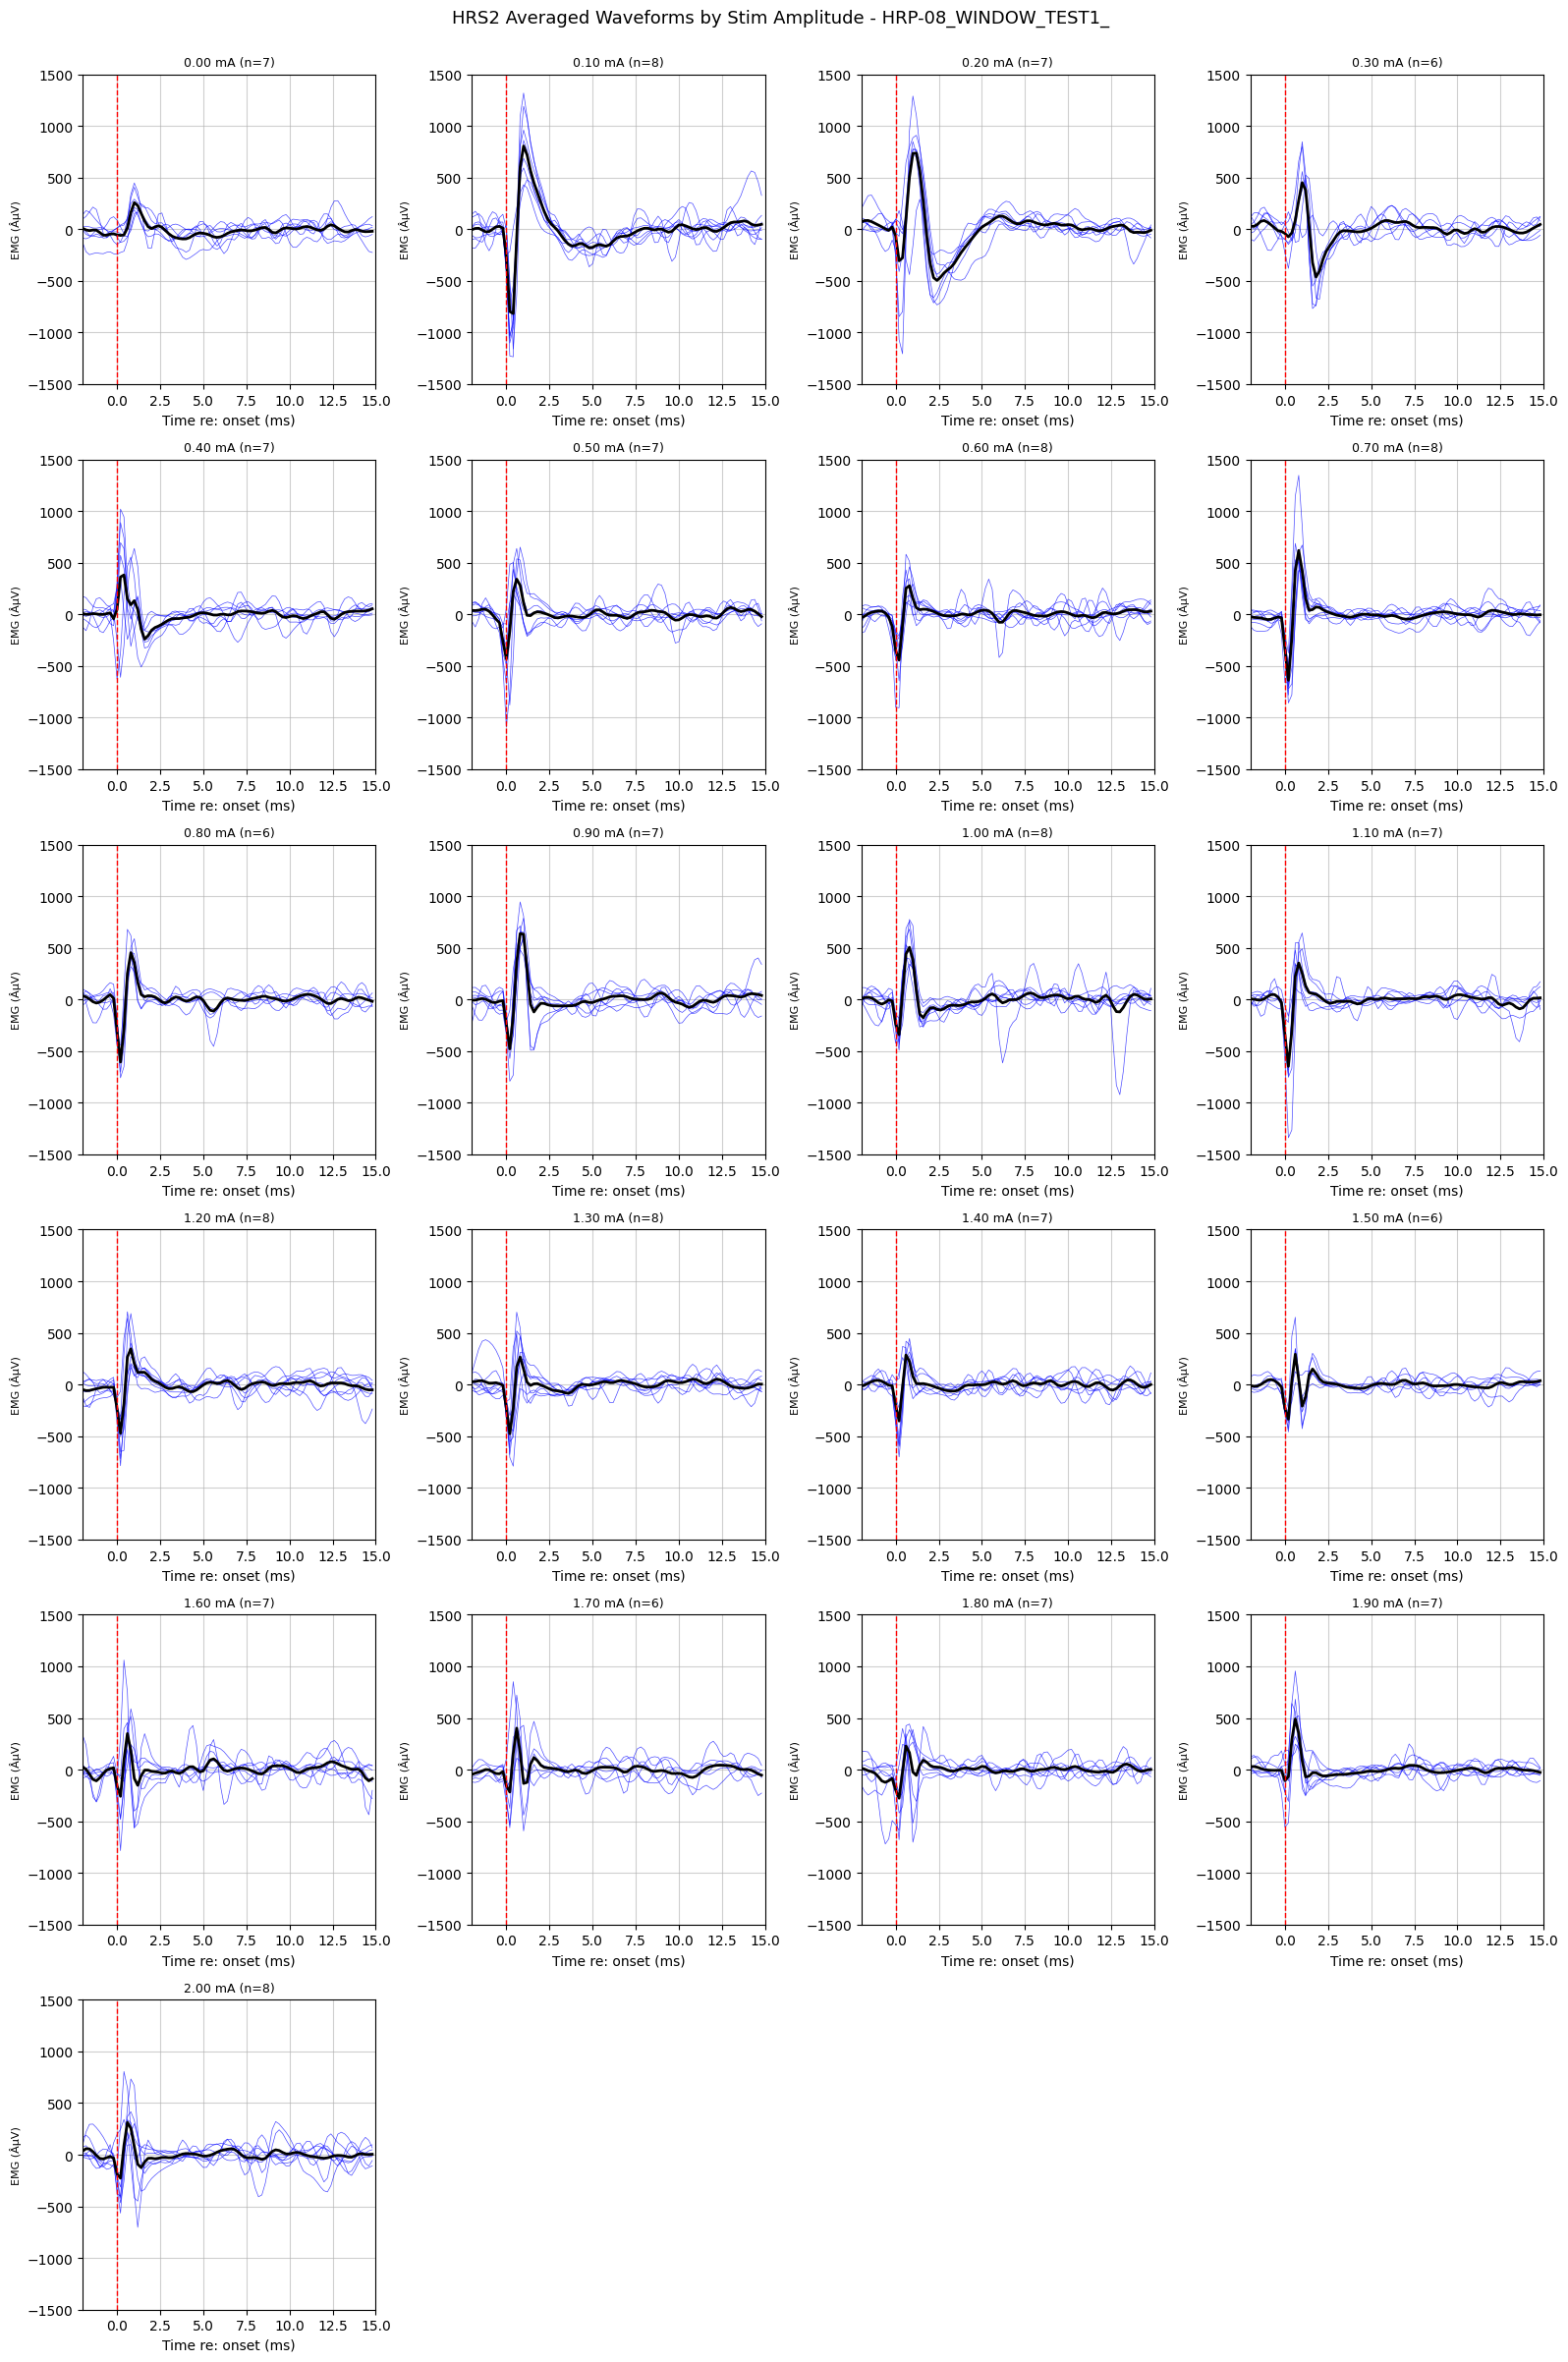

In [58]:

# ---- Plot HRS2: Averaged Waveforms Grouped by Stimulation Amplitude ----
# Trials are aligned to detected stim onset via get_trial_window() before averaging.
from collections import defaultdict

PRE_AVG_MS  = 2   # ms before stim onset
POST_AVG_MS = 15   # ms after  stim onset

if len(hrs2_trials) > 0:
    # Build onset-aligned windows grouped by amplitude
    groups = defaultdict(list)
    for trial in hrs2_trials:
        key = round(trial.stimulation_amplitude_ma, 2)
        t_ms_win, emg_win, _, _ = get_trial_window(trial, PRE_AVG_MS, POST_AVG_MS)
        groups[key].append((t_ms_win, emg_win))

    # Shared y-limits across all individual traces (same approach as interactive viewer)
    _all_emg = np.concatenate([emg for windows in groups.values() for _, emg in windows])
    _lo, _hi = float(np.nanmin(_all_emg)), float(np.nanmax(_all_emg))
    _pad = max(0.08 * (_hi - _lo), 1.0)
    shared_ylim2 = (_lo - _pad, _hi + _pad)

    sorted_amps = sorted(groups.keys())
    n_groups = len(sorted_amps)
    n_cols = 4
    n_rows = int(np.ceil(n_groups / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
    axes = np.array(axes).flatten()

    for idx, amp in enumerate(sorted_amps):
        ax = axes[idx]
        windows = groups[amp]

        t_ref = windows[0][0]
        n_pts = len(t_ref)

        padded = np.full((len(windows), n_pts), np.nan)
        for k, (_, emg) in enumerate(windows):
            n = min(len(emg), n_pts)
            padded[k, :n] = emg[:n]

        avg = np.nanmean(padded, axis=0)

        for row in padded:
            ax.plot(t_ref, row, color='blue', alpha=0.7, linewidth=0.5)

        ax.plot(t_ref, avg, color='black', linewidth=2)
        ax.axvline(0, color='red', linestyle='--', linewidth=1, label='Stim onset')
        ax.set_title(f'{amp:.2f} mA (n={len(windows)})', fontsize=9)
        ax.set_xlim(-PRE_AVG_MS, POST_AVG_MS)
        ax.set_ylim(shared_ylim)
        ax.grid(True, alpha=0.6)
        ax.set_xlabel('Time re: onset (ms)')
        ax.set_ylabel('EMG (ÂµV)', fontsize=8)

    for j in range(n_groups, len(axes)):
        axes[j].axis('off')

    print(f"Shared EMG y-axis: [{shared_ylim[0]:.1f}, {shared_ylim[1]:.1f}] ÂµV")
    fig.suptitle(f'HRS2 Averaged Waveforms by Stim Amplitude - {hrs2_header.subject_id}',
                 fontsize=13, y=1.00)
    plt.tight_layout()
    plt.show()
else:
    print("No HRS2 trials to group.")

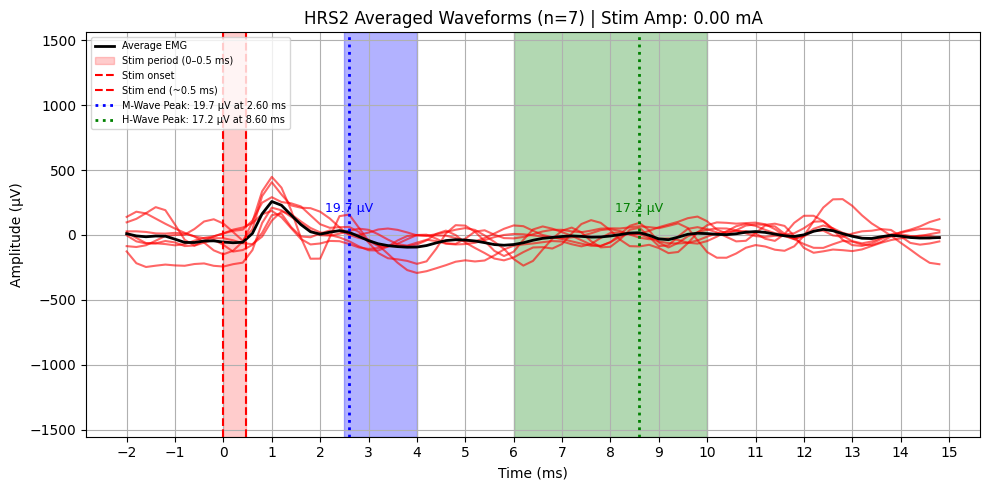

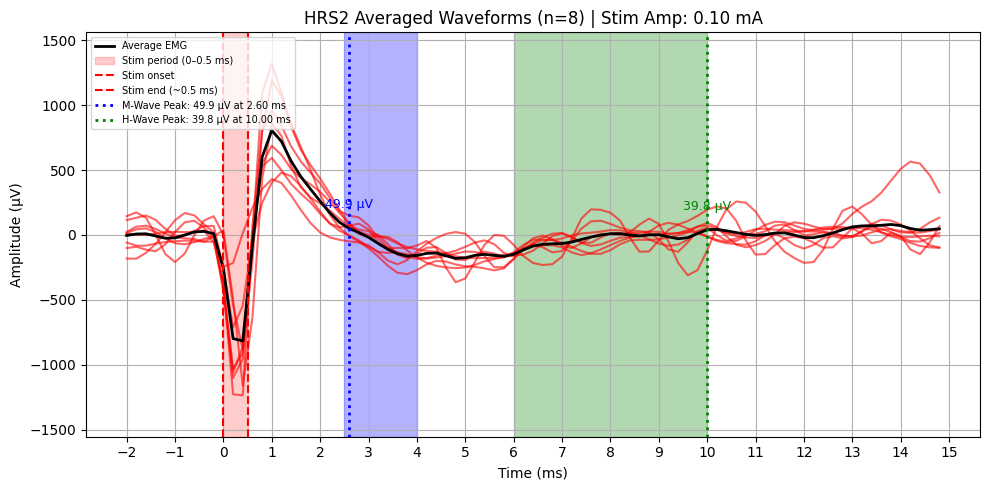

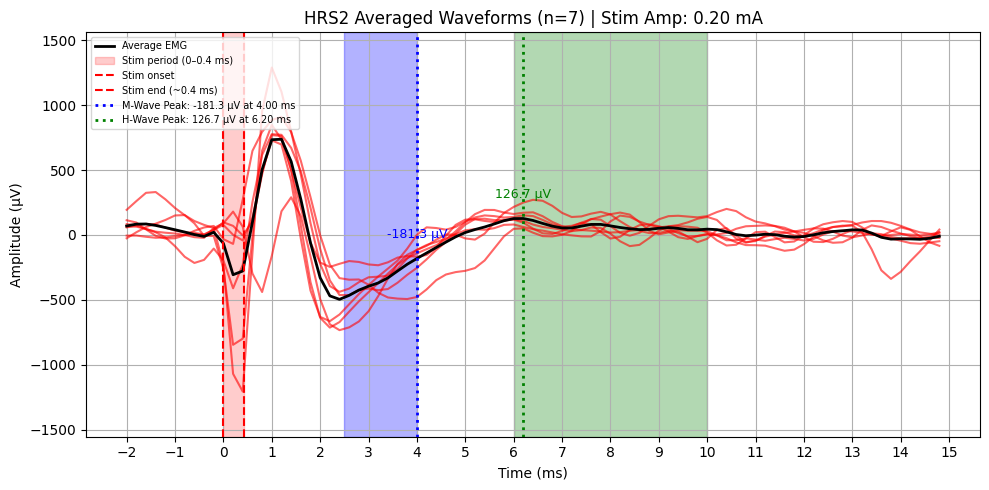

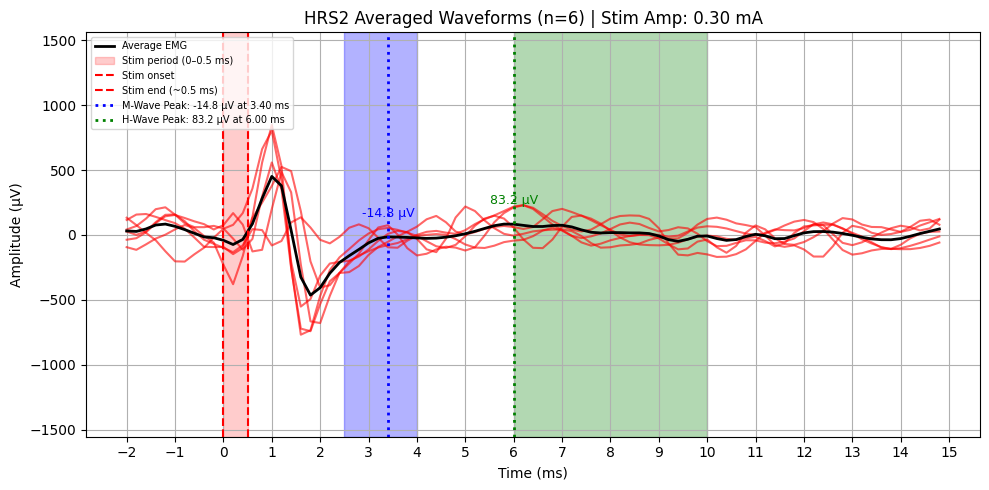

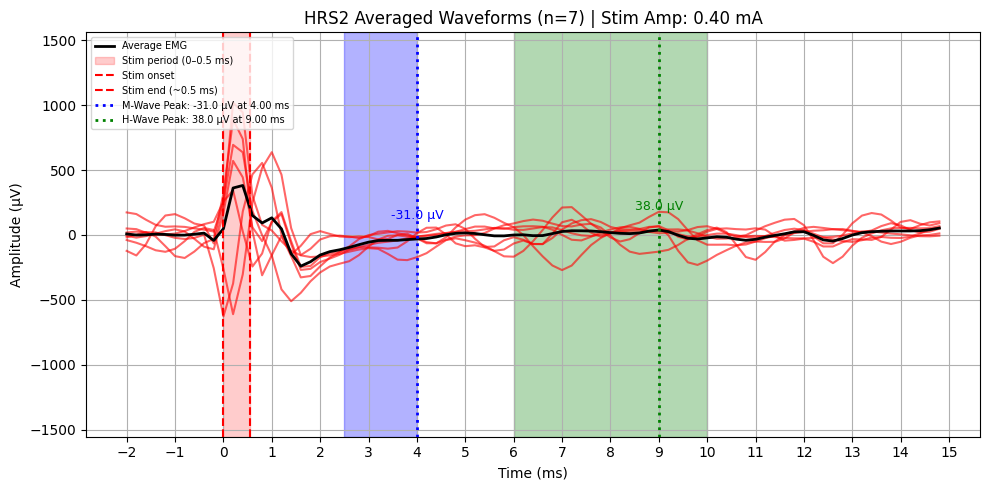

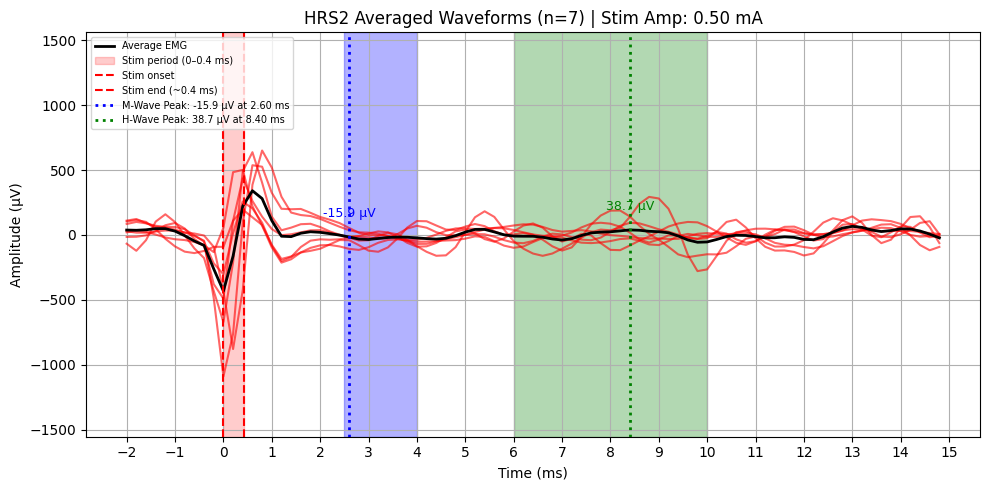

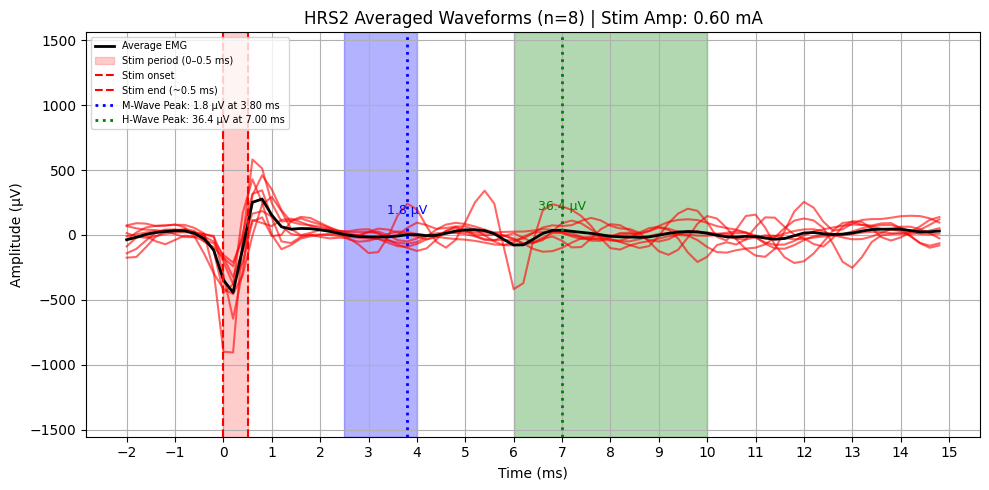

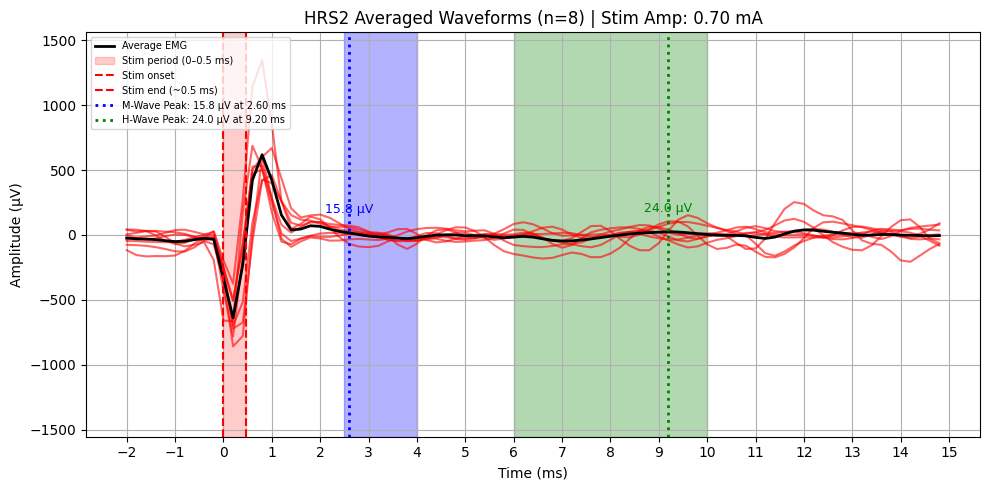

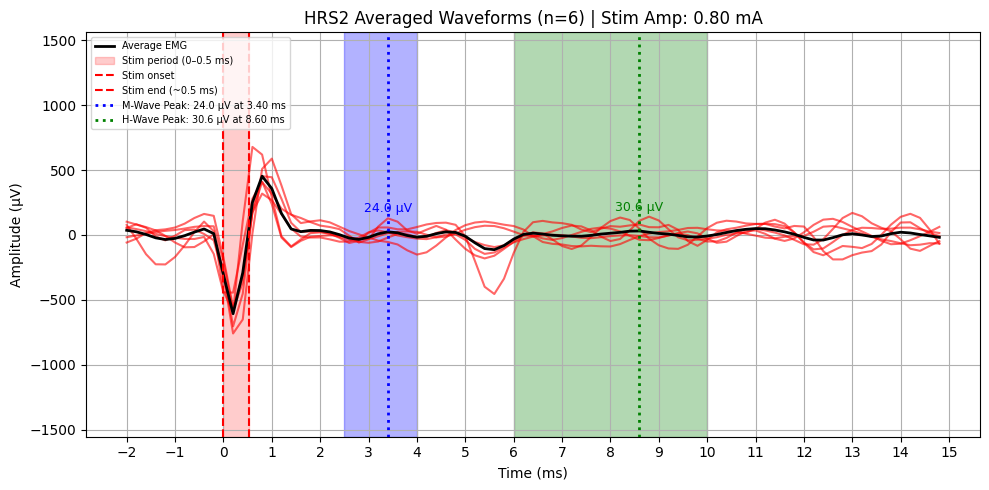

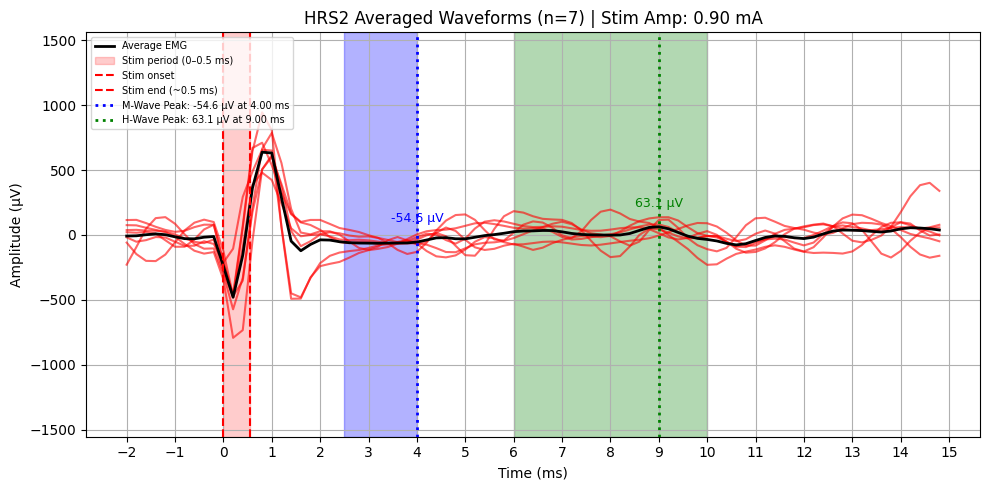

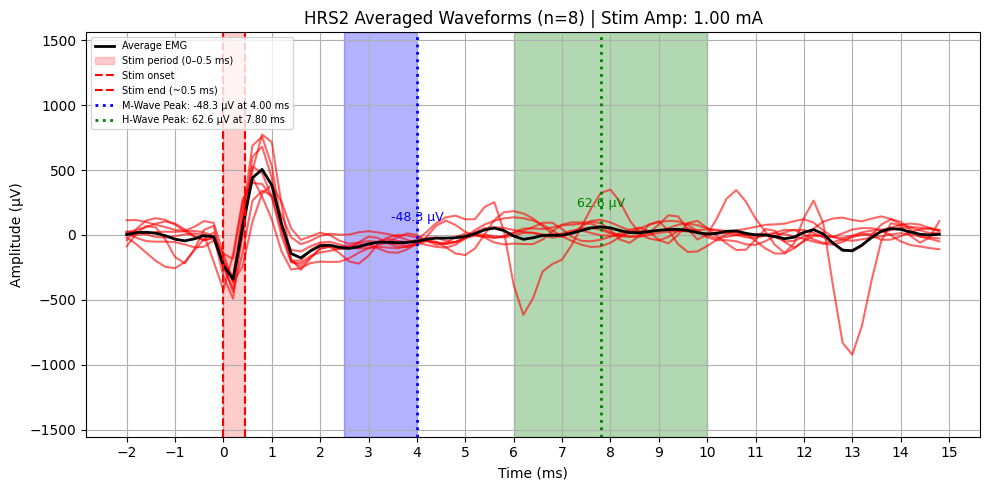

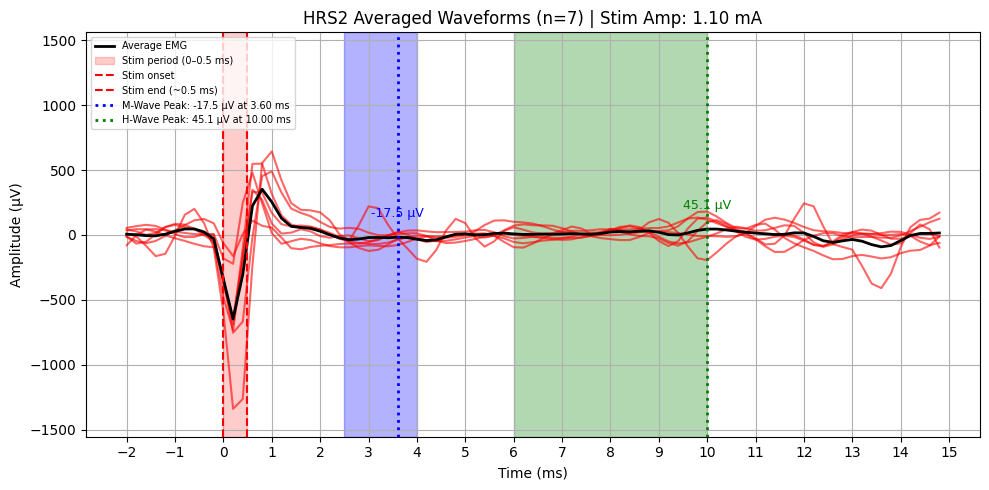

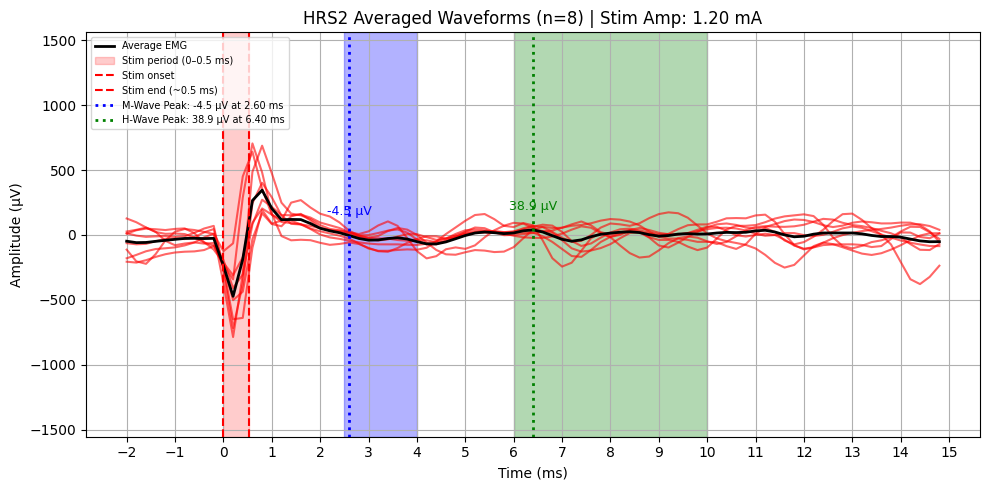

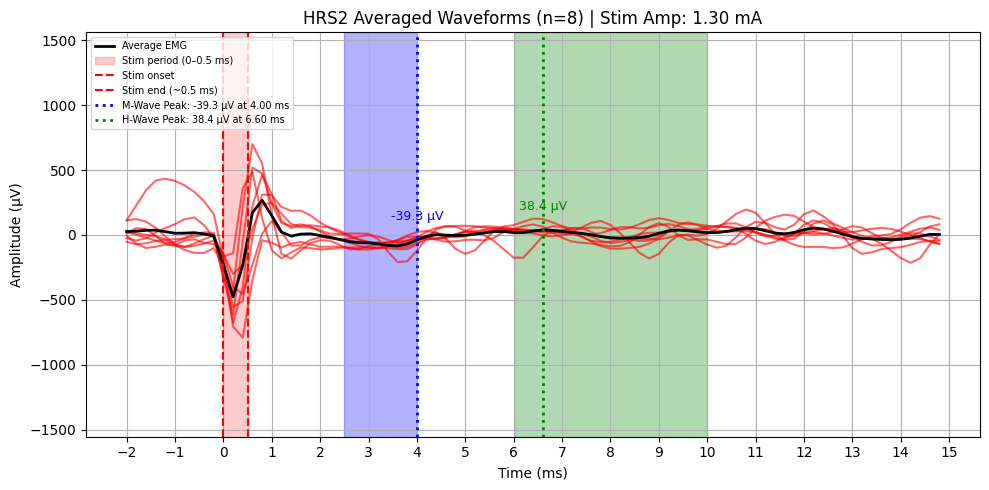

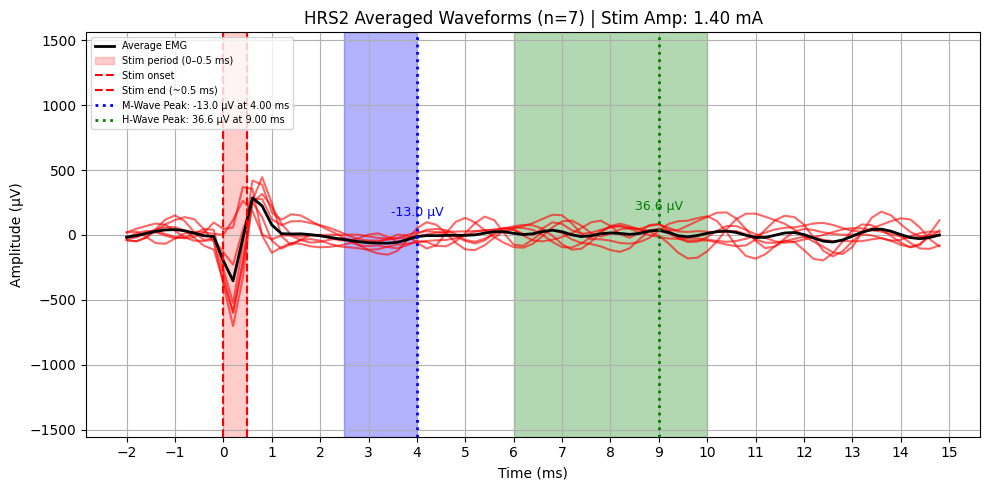

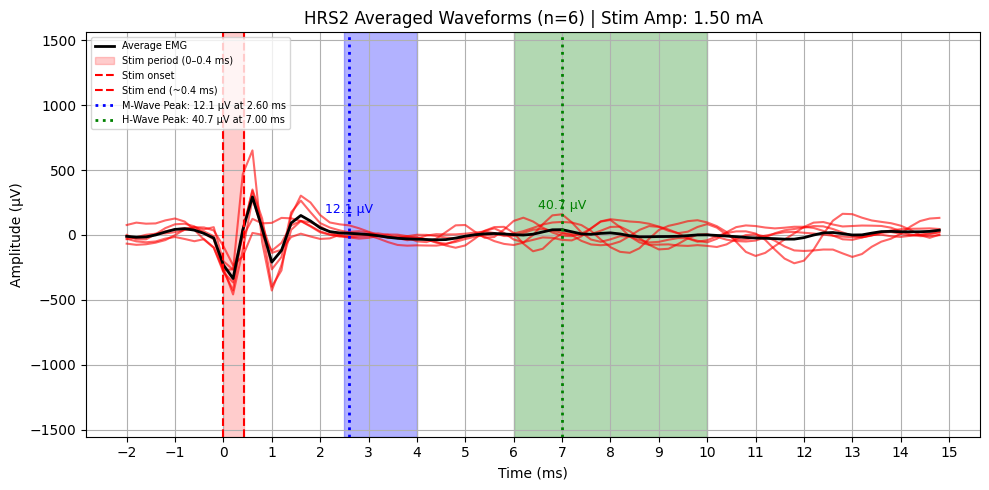

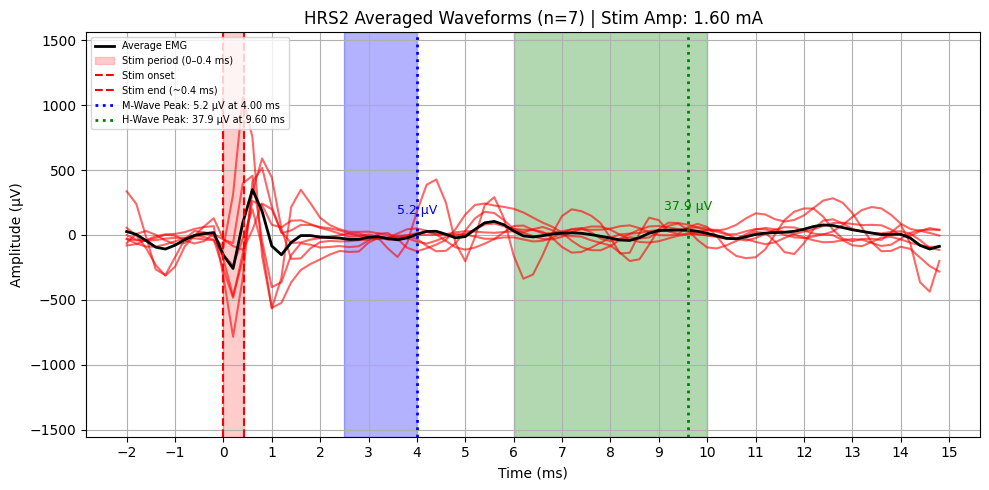

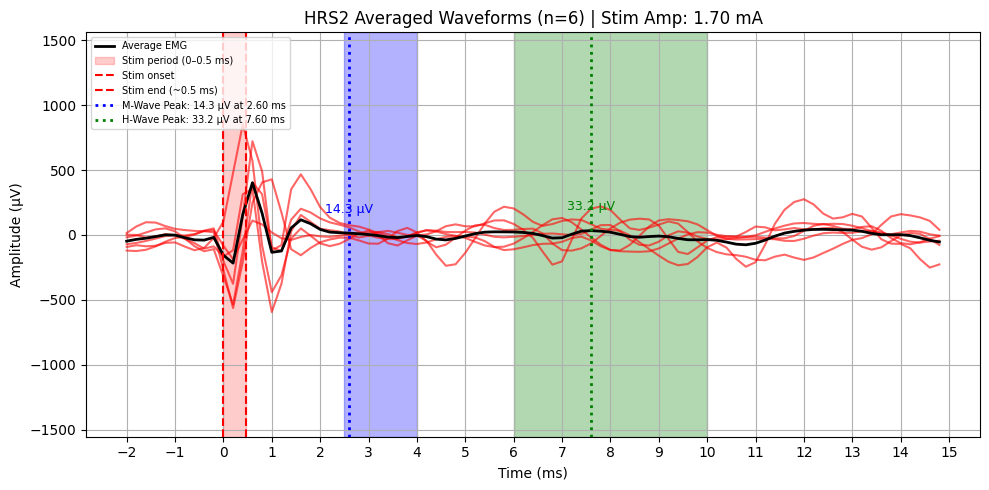

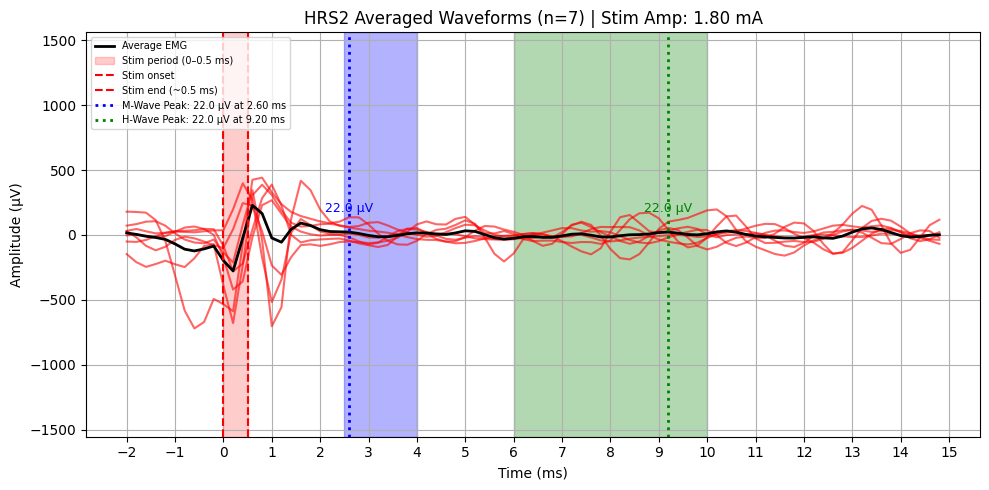

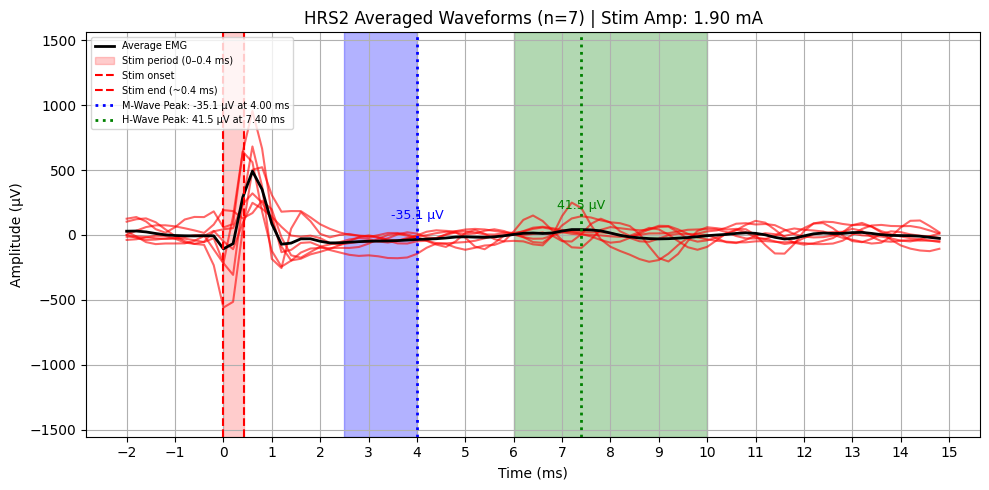

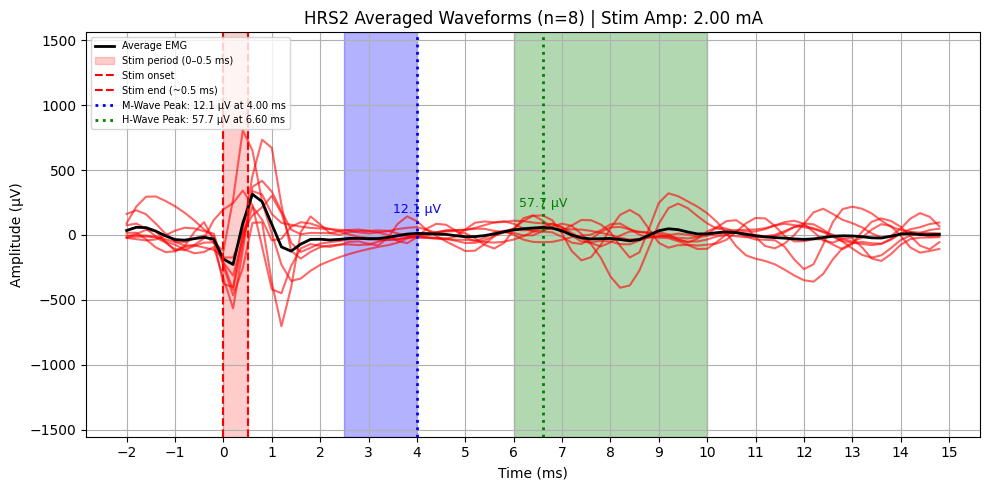

In [64]:
# ---- Plot HRS2: Averaged Waveforms Grouped by Stimulation Amplitude ----
# Trials are aligned to detected stim onset via get_trial_window() before averaging.
# M- and H-wave windows are shaded on every plot.
# A red overlay marks the stimulation period (onset to end).
from collections import defaultdict

PRE_AVG_MS  = 2   # ms before stim onset
POST_AVG_MS = 15  # ms after  stim onset

M_WAVE_START_MS = 2.5
M_WAVE_END_MS   = 4.0
H_WAVE_START_MS = 6.0
H_WAVE_END_MS   = 10.0

if len(hrs2_trials) > 0:
    # Build onset-aligned windows grouped by amplitude, capturing stim_end_ms
    groups = defaultdict(list)
    for trial in hrs2_trials:
        key = round(trial.stimulation_amplitude_ma, 2)
        t_ms_win, emg_win, _, stim_end = get_trial_window(trial, PRE_AVG_MS, POST_AVG_MS)
        groups[key].append((t_ms_win, emg_win, stim_end))

    # Shared y-limits across all individual traces
    _all_emg = np.concatenate([emg for windows in groups.values() for _, emg, _ in windows])
    _lo, _hi = float(np.nanmin(_all_emg)), float(np.nanmax(_all_emg))
    _pad = max(0.08 * (_hi - _lo), 1.0)
    shared_ylim = (_lo - _pad, _hi + _pad)
    _text_offset = 0.05 * (shared_ylim[1] - shared_ylim[0])

    sorted_amps = sorted(groups.keys())

    for amp in sorted_amps:
        windows = groups[amp]

        t_ref = windows[0][0]
        n_pts = len(t_ref)

        padded = np.full((len(windows), n_pts), np.nan)
        for k, (_, emg, _se) in enumerate(windows):
            n = min(len(emg), n_pts)
            padded[k, :n] = emg[:n]

        avg = np.nanmean(padded, axis=0)

        # Compute mean stim end across trials in this group
        stim_ends = [se for _, _, se in windows if se is not None]
        mean_stim_end = float(np.mean(stim_ends)) if stim_ends else 0.5

        plt.figure(figsize=(10, 5))

        for row in padded:
            plt.plot(t_ref, row, color='red', alpha=0.6)
        plt.plot(t_ref, avg, color='black', linewidth=2, label='Average EMG')

        # Stimulation period overlay (red span from onset to end)
        plt.axvspan(0, mean_stim_end, color='red', alpha=0.20,
                    label=f'Stim period (0–{mean_stim_end:.1f} ms)')
        plt.axvline(x=0,              color='red', linestyle='--', label='Stim onset')
        plt.axvline(x=mean_stim_end,  color='red', linestyle='--',
                    label=f'Stim end (~{mean_stim_end:.1f} ms)')

        plt.axvspan(M_WAVE_START_MS, M_WAVE_END_MS, color='blue',  alpha=0.3)
        plt.axvspan(H_WAVE_START_MS, H_WAVE_END_MS, color='green', alpha=0.3)

        # --- Peak detection on average signal ---
        m_wave_mask = (t_ref >= M_WAVE_START_MS) & (t_ref <= M_WAVE_END_MS)
        m_wave_t    = t_ref[m_wave_mask]
        m_wave_emg  = avg[m_wave_mask]
        m_peak_idx  = np.argmax(m_wave_emg)
        m_peak_time = m_wave_t[m_peak_idx]
        m_peak_amp  = m_wave_emg[m_peak_idx]

        h_wave_mask = (t_ref >= H_WAVE_START_MS) & (t_ref <= H_WAVE_END_MS)
        h_wave_t    = t_ref[h_wave_mask]
        h_wave_emg  = avg[h_wave_mask]
        h_peak_idx  = np.argmax(h_wave_emg)
        h_peak_time = h_wave_t[h_peak_idx]
        h_peak_amp  = h_wave_emg[h_peak_idx]

        plt.axvline(x=m_peak_time, color='blue', linestyle=':', linewidth=2,
                    label=f'M-Wave Peak: {m_peak_amp:.1f} μV at {m_peak_time:.2f} ms')
        plt.axvline(x=h_peak_time, color='green', linestyle=':', linewidth=2,
                    label=f'H-Wave Peak: {h_peak_amp:.1f} μV at {h_peak_time:.2f} ms')

        plt.text(m_peak_time, m_peak_amp + _text_offset, f'{m_peak_amp:.1f} μV',
                 color='blue', fontsize=9, ha='center')
        plt.text(h_peak_time, h_peak_amp + _text_offset, f'{h_peak_amp:.1f} μV',
                 color='green', fontsize=9, ha='center')

        plt.title(f"HRS2 Averaged Waveforms (n={len(windows)}) | Stim Amp: {amp:.2f} mA")
        plt.xlabel("Time (ms)")
        plt.ylabel("Amplitude (μV)")
        plt.grid(True)
        plt.legend(
            fontsize=7,
            loc="upper left",
            frameon=True,
            framealpha=0.8
        )
        plt.ylim(shared_ylim)

        min_ms = int(np.floor(t_ref[0]))
        max_ms = int(np.ceil(t_ref[-1]))
        plt.xticks(np.arange(min_ms, max_ms + 1, 1))

        plt.tight_layout()
        plt.show()
else:
    print("No HRS2 trials to group.")

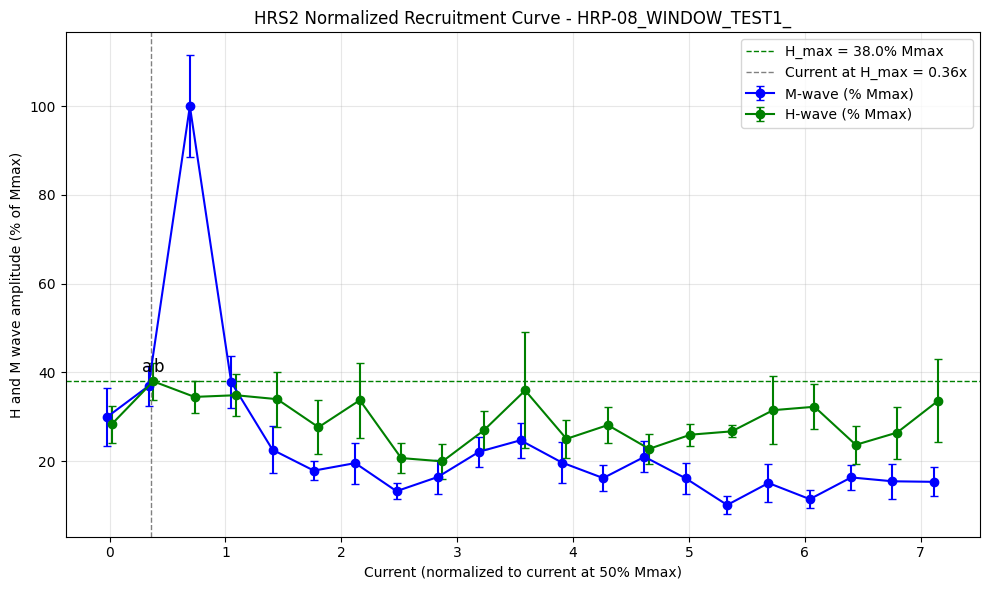

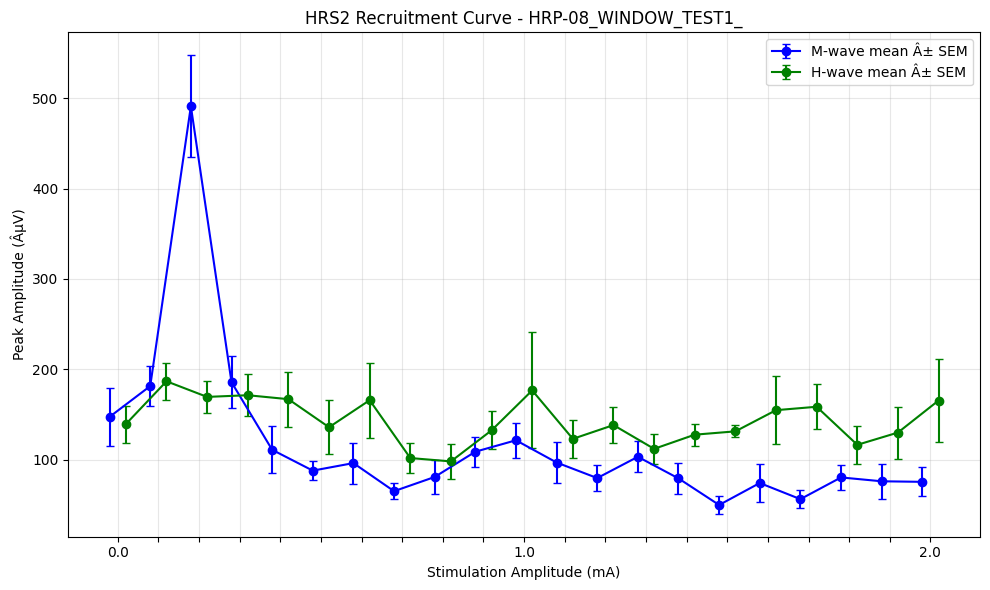

M_max = 491.22 ÂµV
H_max = 186.68 ÂµV (38.0% of M_max)
Current at 50% M_max = 0.28 mA
Current at H_max = 0.10 mA (0.36x normalized)


In [60]:
# ---- Plot HRS2: Recruitment Curve (M-wave and H-wave peak amplitudes) ----
# Uses get_trial_window() so M/H windows are relative to the detected stim onset.

import scipy.stats as stats
from scipy.interpolate import interp1d
from collections import defaultdict

M_WAVE_START_MS = 2.5
M_WAVE_END_MS   = 4.0
H_WAVE_START_MS = 6.0
H_WAVE_END_MS   = 10.0

_PRE_RC  = max(M_WAVE_START_MS, H_WAVE_START_MS) + 1.0
_POST_RC = H_WAVE_END_MS + 2.0

if len(hrs2_trials) > 0:
    m_wave_dict = defaultdict(list)
    h_wave_dict = defaultdict(list)

    for trial in hrs2_trials:
        amp_key = round(trial.stimulation_amplitude_ma, 2)
        t_ms, emg, _, _ = get_trial_window(trial, _PRE_RC, _POST_RC)

        m_mask = (t_ms >= M_WAVE_START_MS) & (t_ms <= M_WAVE_END_MS)
        if np.any(m_mask):
            m_wave_dict[amp_key].append(np.max(np.abs(emg[m_mask])))

        h_mask = (t_ms >= H_WAVE_START_MS) & (t_ms <= H_WAVE_END_MS)
        if np.any(h_mask):
            h_wave_dict[amp_key].append(np.max(np.abs(emg[h_mask])))

    sorted_amps = sorted(set(m_wave_dict.keys()) | set(h_wave_dict.keys()))
    m_wave_data = [m_wave_dict.get(a, [0]) for a in sorted_amps]
    h_wave_data = [h_wave_dict.get(a, [0]) for a in sorted_amps]

    m_means = np.array([np.mean(v) for v in m_wave_data])
    h_means = np.array([np.mean(v) for v in h_wave_data])
    m_sems  = np.array([stats.sem(v) if len(v) > 1 else 0 for v in m_wave_data])
    h_sems  = np.array([stats.sem(v) if len(v) > 1 else 0 for v in h_wave_data])

    # ---- Normalize to M_max ----
    M_max = np.max(m_means) if np.max(m_means) > 0 else 1
    m_means_norm = (m_means / M_max) * 100
    h_means_norm = (h_means / M_max) * 100
    m_sems_norm  = (m_sems  / M_max) * 100
    h_sems_norm  = (h_sems  / M_max) * 100

    # ---- Current at 50% Mmax (for normalized x-axis) ----
    interp_func = interp1d(m_means_norm, sorted_amps, kind='linear',
                           bounds_error=False, fill_value='extrapolate')
    try:
        current_at_50 = float(interp_func(50))
    except Exception:
        current_at_50 = sorted_amps[np.argmax(m_means_norm >= 50)]

    normalized_currents = np.array(sorted_amps) / current_at_50

    # H_max annotation points
    H_max = np.max(h_means_norm)
    idx_Hmax = int(np.argmax(h_means_norm))
    current_at_Hmax_norm = normalized_currents[idx_Hmax]

    # ---- Plot 1: Normalized recruitment curve (current normalized to 50% Mmax) ----
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.errorbar(normalized_currents - 0.02, m_means_norm, yerr=m_sems_norm,
                fmt='o-', color='blue',  label='M-wave (% Mmax)', capsize=3)
    ax.errorbar(normalized_currents + 0.02, h_means_norm, yerr=h_sems_norm,
                fmt='o-', color='green', label='H-wave (% Mmax)', capsize=3)

    ax.axhline(H_max, color='green', linestyle='--', linewidth=1,
               label=f'H_max = {H_max:.1f}% Mmax')
    ax.axvline(current_at_Hmax_norm, color='gray', linestyle='--', linewidth=1,
               label=f'Current at H_max = {current_at_Hmax_norm:.2f}x')

    ax.text(current_at_Hmax_norm + 0.02, H_max + 2, 'b', fontsize=12, color='black')
    ax.text(normalized_currents[idx_Hmax] - 0.08, H_max + 2, 'a', fontsize=12, color='black')

    ax.set_xlabel('Current (normalized to current at 50% Mmax)')
    ax.set_ylabel('H and M wave amplitude (% of Mmax)')
    ax.set_title(f'HRS2 Normalized Recruitment Curve - {hrs2_header.subject_id}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # ---- Plot 2: Raw amplitude mean Â± SEM vs stimulation amplitude ----
    fig, ax = plt.subplots(figsize=(10, 6))
    positions = np.arange(len(sorted_amps))

    ax.errorbar(positions - 0.2, m_means, yerr=m_sems, fmt='o-', color='blue',
                label='M-wave mean Â± SEM', capsize=3)
    ax.errorbar(positions + 0.2, h_means, yerr=h_sems, fmt='o-', color='green',
                label='H-wave mean Â± SEM', capsize=3)

    ax.set_xticks(positions)
    tick_labels = [f'{a:.1f}' if i % 10 == 0 else '' for i, a in enumerate(sorted_amps)]
    ax.set_xticklabels(tick_labels)
    ax.set_xlabel('Stimulation Amplitude (mA)')
    ax.set_ylabel('Peak Amplitude (ÂµV)')
    ax.set_title(f'HRS2 Recruitment Curve - {hrs2_header.subject_id}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"M_max = {M_max:.2f} ÂµV")
    print(f"H_max = {np.max(h_means):.2f} ÂµV ({H_max:.1f}% of M_max)")
    print(f"Current at 50% M_max = {current_at_50:.2f} mA")
    print(f"Current at H_max = {sorted_amps[idx_Hmax]:.2f} mA ({current_at_Hmax_norm:.2f}x normalized)")
else:
    print("No HRS2 trials available for recruitment curve.")

# Section 4: Polarity Test â€” CORRECT vs FLIPPED Electrode Orientation

This section loads both polarity test recordings and compares them side-by-side.

The app applies `|ADC sync|` (absolute value) on the ADC sync line so that stim-onset detection works regardless of electrode orientation.  
The raw EMG differential signal (`CH8 âˆ’ CH7`) will appear **inverted** when the electrodes are swapped.

- **`HR-08-POLARITY_TEST_CORRECT`** â€” electrodes attached with standard orientation
- **`HR-08-POLARITY_TEST_FLIPPED_`** â€” electrodes attached with reversed orientation

In [61]:
# ---- Load both polarity recordings ----
_correct_dir = "HR-08-POLARITY_TEST_CORRECT"
_flipped_dir = "HR-08-POLARITY_TEST_FLIPPED_"

_hrs1_correct_path, _hrs2_correct_path = find_hrs_files(_correct_dir)
_hrs1_flipped_path, _hrs2_flipped_path = find_hrs_files(_flipped_dir)

_h2c, _t2c, _e2c = read_hrs2(_hrs2_correct_path)
_h2f, _t2f, _e2f = read_hrs2(_hrs2_flipped_path)

print(f"CORRECT : {os.path.basename(_hrs2_correct_path)}")
print(f"  file_version={_h2c.file_version}  trials={len(_t2c)}  emg_blocks={len(_e2c)}")
print(f"  channels: {_e2c[0].channel_names if _e2c else 'n/a'}")
print()
print(f"FLIPPED : {os.path.basename(_hrs2_flipped_path)}")
print(f"  file_version={_h2f.file_version}  trials={len(_t2f)}  emg_blocks={len(_e2f)}")
print(f"  channels: {_e2f[0].channel_names if _e2f else 'n/a'}")

# Find amplitudes present in both recordings
_amps_c = set(round(t.stimulation_amplitude_ma, 2) for t in _t2c)
_amps_f = set(round(t.stimulation_amplitude_ma, 2) for t in _t2f)
_shared_amps = sorted(_amps_c & _amps_f)
print(f"\nShared stim amplitudes ({len(_shared_amps)}): {_shared_amps}")

CORRECT : HR-08-POLARITY_TEST_CORRECT_20260324T110246.hrs2
  file_version=2  trials=27  emg_blocks=2297
  channels: ['CH7', 'CH8', 'ADC1']

FLIPPED : HR-08-POLARITY_TEST_FLIPPED__20260324T113235.hrs2
  file_version=2  trials=25  emg_blocks=2253
  channels: ['CH7', 'CH8', 'ADC1']

Shared stim amplitudes (15): [0.1, 0.2, 0.4, 0.5, 0.6, 0.7, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.7, 1.8, 2.0]


In [62]:
# ---- Polarity Comparison: Interactive Paged Viewer ----
# 2x2 grid per page: 2 stimulus amplitudes per page.
# Top row = CORRECT polarity, bottom row = FLIPPED polarity.
# M- and H-wave windows are shaded on every panel.
# Requires an interactive Jupyter kernel (ipywidgets).

from collections import defaultdict
from ipywidgets import Button, Output, HBox, VBox, Dropdown, Label
from matplotlib.patches import Patch as _Patch

_PRE_COMP_MS  = 5.0
_POST_COMP_MS = 20.0

_COMP_M_WAVE_START_MS = 2.5
_COMP_M_WAVE_END_MS   = 4.0
_COMP_H_WAVE_START_MS = 6.0
_COMP_H_WAVE_END_MS   = 10.0

def _build_avg_groups(trials, pre_ms, post_ms):
    groups = defaultdict(list)
    for tr in trials:
        key = round(tr.stimulation_amplitude_ma, 2)
        t_ms, emg, _, _ = get_trial_window(tr, pre_ms, post_ms)
        groups[key].append((t_ms, emg))
    return groups

_grp_c = _build_avg_groups(_t2c, _PRE_COMP_MS, _POST_COMP_MS)
_grp_f = _build_avg_groups(_t2f, _PRE_COMP_MS, _POST_COMP_MS)

# 2 amplitudes per page → 4 subplots (2 cols × 2 rows)
_N_AMPS_PER_PAGE = 2
_pol_pages = [_shared_amps[i:i+_N_AMPS_PER_PAGE]
              for i in range(0, len(_shared_amps), _N_AMPS_PER_PAGE)]
_pol_current_page = {'idx': 0}

# Shared y-limits across all polarity traces
_pol_all_emg = np.concatenate([
    emg
    for grp in [_grp_c, _grp_f]
    for windows in grp.values()
    for _, emg in windows
])
_pol_lo, _pol_hi = float(np.nanmin(_pol_all_emg)), float(np.nanmax(_pol_all_emg))
_pol_pad = max(0.08 * (_pol_hi - _pol_lo), 1.0)
_pol_ylim = (_pol_lo - _pol_pad, _pol_hi + _pol_pad)

_pol_out = Output()

def _draw_pol_ax(ax, grp, amp, label, color):
    """Render averaged waveforms for one polarity/amplitude into ax."""
    windows = grp.get(amp, [])
    legend_h, legend_l = [], []

    if windows:
        t_ref = windows[0][0]
        n_pts = len(t_ref)
        padded = np.full((len(windows), n_pts), np.nan)
        for k, (_, emg) in enumerate(windows):
            n = min(len(emg), n_pts)
            padded[k, :n] = emg[:n]
        avg = np.nanmean(padded, axis=0)
        for row_data in padded:
            ax.plot(t_ref, row_data, color=color, alpha=0.25, linewidth=0.5)
        h_avg, = ax.plot(t_ref, avg, color=color, linewidth=2.0)
        legend_h.append(h_avg)
        legend_l.append(f'{label} avg (n={len(windows)})')

    # M/H wave region overlays
    ax.axvspan(_COMP_M_WAVE_START_MS, _COMP_M_WAVE_END_MS, color='blue',  alpha=0.12, zorder=0)
    ax.axvspan(_COMP_H_WAVE_START_MS, _COMP_H_WAVE_END_MS, color='green', alpha=0.12, zorder=0)
    legend_h += [_Patch(facecolor='blue', alpha=0.4), _Patch(facecolor='green', alpha=0.4)]
    legend_l += ['M-wave (2.5–4 ms)', 'H-wave (6–10 ms)']

    h_onset = ax.axvline(0, color='blue', linestyle='--', linewidth=1.0)
    legend_h.append(h_onset)
    legend_l.append('Stim onset')

    ax.axhline(0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)
    ax.set_xlim(-_PRE_COMP_MS, _POST_COMP_MS)
    ax.set_xlabel('Time re: onset (ms)', fontsize=8)
    ax.set_ylabel(f'{label}\nEMG (µV)', fontsize=8)
    ax.set_ylim(_pol_ylim)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.3)
    ax.legend(legend_h, legend_l, fontsize=7, loc='upper right')

def _plot_pol_page(page_idx):
    with _pol_out:
        _pol_out.clear_output(wait=True)
        amps_on_page = _pol_pages[page_idx]
        n_cols = len(amps_on_page)

        fig, axes = plt.subplots(2, n_cols, figsize=(6 * n_cols, 8), sharey='row')
        # Normalize axes to always be 2D array
        if n_cols == 1:
            axes = np.array([[axes[0]], [axes[1]]])
        else:
            axes = np.array(axes)

        for col, amp in enumerate(amps_on_page):
            for row_idx, (grp, label, color) in enumerate([
                    (_grp_c, 'CORRECT', 'black'),
                    (_grp_f, 'FLIPPED', 'firebrick'),
            ]):
                ax = axes[row_idx, col]
                _draw_pol_ax(ax, grp, amp, label, color)
                if row_idx == 0:
                    ax.set_title(f'{amp:.2f} mA', fontsize=10)

        fig.suptitle(
            f'Polarity Comparison — CORRECT vs FLIPPED\n'
            f'({_h2c.subject_id}  vs  {_h2f.subject_id})  '
            f'(Page {page_idx + 1}/{len(_pol_pages)})',
            fontsize=12
        )
        plt.tight_layout()
        plt.show()

def _pol_on_prev(b):
    if _pol_current_page['idx'] > 0:
        _pol_current_page['idx'] -= 1
        _pol_page_drop.value = _pol_current_page['idx']
        _plot_pol_page(_pol_current_page['idx'])

def _pol_on_next(b):
    if _pol_current_page['idx'] < len(_pol_pages) - 1:
        _pol_current_page['idx'] += 1
        _pol_page_drop.value = _pol_current_page['idx']
        _plot_pol_page(_pol_current_page['idx'])

def _pol_on_page_change(change):
    if change['name'] == 'value' and change['new'] != _pol_current_page['idx']:
        _pol_current_page['idx'] = change['new']
        _plot_pol_page(_pol_current_page['idx'])

_pol_prev_btn  = Button(description='Prev', button_style='')
_pol_next_btn  = Button(description='Next', button_style='primary')
_pol_page_drop = Dropdown(
    options=[(f'Page {i+1}', i) for i in range(len(_pol_pages))],
    description='Page:', layout={'width': '130px'}
)

_pol_prev_btn.on_click(_pol_on_prev)
_pol_next_btn.on_click(_pol_on_next)
_pol_page_drop.observe(_pol_on_page_change, names='value')

_pol_controls = HBox([_pol_prev_btn, _pol_next_btn, _pol_page_drop])

print(f"{len(_shared_amps)} shared amplitudes across {len(_pol_pages)} page(s), 2 per page.")
print("Top row: CORRECT polarity  |  Bottom row: FLIPPED polarity")
print("Note: FLIPPED traces should be the vertical mirror image of CORRECT traces.")
display(VBox([_pol_controls, _pol_out]))
_plot_pol_page(0)

15 shared amplitudes across 8 page(s), 2 per page.
Top row: CORRECT polarity  |  Bottom row: FLIPPED polarity
Note: FLIPPED traces should be the vertical mirror image of CORRECT traces.


In [63]:
# ---- Polarity Comparison: ADC sync line robustness ----
# The app applies abs() to the ADC sync line so onset detection is polarity-agnostic.
# This cell confirms that sync_peak_voltage is well above threshold in BOTH recordings.

print("=== ADC Sync Quality Summary ===\n")
for label, trials, hdr in [("CORRECT", _t2c, _h2c), ("FLIPPED", _t2f, _h2f)]:
    if hdr.file_version >= 2:
        peaks   = [t.sync_peak_voltage for t in trials]
        onsets  = [bool(t.onset_detected) for t in trials]
        discard = [t.n_pre_trigger_frames_discarded for t in trials]
        dur_ms  = [t.stim_duration_ms for t in trials if t.stim_end_sample_index >= 0]
        print(f"  {label}  (file_version={hdr.file_version})")
        print(f"    Trials:                     {len(trials)}")
        print(f"    Onset detected:             {sum(onsets)} / {len(onsets)}")
        print(f"    ADC peak  min/mean/max (V): {min(peaks):.3f} / {np.mean(peaks):.3f} / {max(peaks):.3f}"
              f"  (threshold = {STIM_ONSET_THRESHOLD} V)")
        print(f"    Stim dur  min/mean/max (ms):{min(dur_ms):.2f} / {np.mean(dur_ms):.2f} / {max(dur_ms):.2f}"
              if dur_ms else "    Stim dur: n/a (end not detected)")
        print(f"    Pre-trigger frames discarded (total): {sum(discard)}")
        print()
    else:
        print(f"  {label}  (file_version={hdr.file_version}) â€” v2 fields not available\n")

=== ADC Sync Quality Summary ===

  CORRECT  (file_version=2)
    Trials:                     27
    Onset detected:             27 / 27
    ADC peak  min/mean/max (V): 5.346 / 5.349 / 5.351  (threshold = 4.5 V)
    Stim dur  min/mean/max (ms):0.40 / 0.46 / 0.60
    Pre-trigger frames discarded (total): 54

  FLIPPED  (file_version=2)
    Trials:                     25
    Onset detected:             25 / 25
    ADC peak  min/mean/max (V): 5.344 / 5.348 / 5.351  (threshold = 4.5 V)
    Stim dur  min/mean/max (ms):0.40 / 0.50 / 0.60
    Pre-trigger frames discarded (total): 56

